# Lab 02 — Time-Series Methods

Lab 01 built five baselines and found that the window defining "recent history" mattered as much
as the statistic computed over it. This lab pushes on the same idea in three directions:

- **shape instead of level** — the matrix profile, which asks whether a stretch of signal has
  ever happened before, and whose only parameter is a window;
- **context instead of magnitude** — a bulk transfer at 01:00 that is perfectly ordinary at
  14:00, which every model in Lab 01 would miss;
- **structure instead of points** — change-point detection, which asks whether the system moved
  to a new level rather than whether one sample was large.

Lab 01's two words carry over unchanged: *anomaly* names ground truth, *alert* names what a
detector emitted. `ANOMALY_TYPES` selects which labelled anomalies this run is scored against.

## Learning outcomes

1. Detect and measure the daily cycle, and split and scale a series without leaking the future.
2. Build a matrix profile in numpy and read its discord, and see what its window length costs.
3. Watch `IsolationForest`, `OneClassSVM` and `LocalOutlierFactor` miss a contextual anomaly
   completely on raw values, then recover it two ways.
4. Sweep the sliding-window length and see the same two-sided failure Lab 01 found.
5. Detect a change point with a two-window score and with CUSUM, and correlate it with the change
   calendar before calling it an incident.

## Step 1 — Libraries and figure settings

Every figure setting in this notebook is made here and nowhere else. No cell below sets a font
size, a line width, a marker size or a colour.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import matplotlib
import matplotlib.pyplot as plt
from cycler import cycler
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

# Same meanings as Lab 01: blue is the measured signal, orange a baseline or a ground-truth
# window, purple a derived score, red an alert or a limit, green a peer method.
C = {"signal": "#3B7DD8", "baseline": "#E0752D", "score": "#7A5AC7",
     "alert": "#D6455D", "truth": "#FF9F1C", "peer": "#2E9E7B", "muted": "#9AA4B0"}
PORT_C = ["#3B7DD8", "#E0752D", "#2E9E7B", "#7A5AC7", "#B04A6E"]

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (14, 4.6),
    "font.size": 14,
    "axes.titlesize": 16, "axes.titlelocation": "left", "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "figure.titlesize": 18,
    "lines.linewidth": 1.4, "lines.markersize": 7,
    "scatter.edgecolors": "white",
    "axes.prop_cycle": cycler(color=PORT_C),
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.autolayout": True,
})
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)

for m in (np, pd, scipy, matplotlib):
    print(f"{m.__name__:12} {m.__version__}")

numpy        2.4.6
pandas       3.0.3
scipy        1.17.1
matplotlib   3.10.9


## Step 2 — Load the data into `df`

The same 30 days of SNMP counters as Lab 01, and the same 13 features, defined identically. Seven
are scorable and six are degenerate, meaning over half their samples are exactly zero. That split is
Lab 01's measurement, and Step 12 is where it stops being a footnote.

In [2]:
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "environments").is_dir():
    ROOT = ROOT.parent
DATA = ROOT / "data" / "synthetic"

df = pd.read_csv(DATA / "synthetic_rrd_metrics.csv", parse_dates=["timestamp"])
df = df.sort_values(["port_id", "timestamp"]).reset_index(drop=True)

bytes_all = df["INOCTETS"] + df["OUTOCTETS"]
pkts_all = (df["INUCASTPKTS"] + df["OUTUCASTPKTS"] + df["INNUCASTPKTS"] + df["OUTNUCASTPKTS"]
            + df["INBROADCASTPKTS"] + df["OUTBROADCASTPKTS"]
            + df["INMULTICASTPKTS"] + df["OUTMULTICASTPKTS"]).clip(lower=1)

# The same 13 features Lab 01 builds, defined identically. Five volume, eight shape.
df["traffic_bps"]       = bytes_all * 8 / 300
df["packets_pps"]       = pkts_all / 300
df["errors_pps"]        = (df["INERRORS"] + df["OUTERRORS"]) / 300
df["discards_pps"]      = (df["INDISCARDS"] + df["OUTDISCARDS"]) / 300
df["unknown_proto_pps"] = df["INUNKNOWNPROTOS"] / 300
df["avg_pkt_bytes"]     = bytes_all / pkts_all
df["broadcast_ratio"]   = (df["INBROADCASTPKTS"] + df["OUTBROADCASTPKTS"]) / pkts_all
df["multicast_ratio"]   = (df["INMULTICASTPKTS"] + df["OUTMULTICASTPKTS"]) / pkts_all
df["nonucast_ratio"]    = (df["INNUCASTPKTS"] + df["OUTNUCASTPKTS"]) / pkts_all
df["tx_ratio"]          = df["OUTOCTETS"] / bytes_all.clip(lower=1)
df["error_rate"]        = (df["INERRORS"] + df["OUTERRORS"]) / pkts_all
df["discard_rate"]      = (df["INDISCARDS"] + df["OUTDISCARDS"]) / pkts_all
df["err_disc_rate"]     = (df["INERRORS"] + df["OUTERRORS"]
                           + df["INDISCARDS"] + df["OUTDISCARDS"]) / pkts_all

FEATURES = ["traffic_bps", "packets_pps", "errors_pps", "discards_pps", "unknown_proto_pps",
            "avg_pkt_bytes", "broadcast_ratio", "multicast_ratio", "nonucast_ratio",
            "tx_ratio", "error_rate", "discard_rate", "err_disc_rate"]
zero_fraction = (df[FEATURES] == 0).mean()
SCORABLE = [c for c in FEATURES if zero_fraction[c] <= 0.5]
DEGENERATE = [c for c in FEATURES if zero_fraction[c] > 0.5]
print(f"{len(SCORABLE)} scorable, {len(DEGENERATE)} degenerate (over half zeros)")

CADENCE = df.groupby("port_id")["timestamp"].diff().dt.total_seconds().median()
# Counters are totals over a 5-minute bucket, so a timestamp names an interval rather than an
# instant. Every shaded window below is widened by HALF so it covers the samples it contains
# instead of only their centres.
HALF = pd.Timedelta(seconds=CADENCE / 2)
DAYS = (df["timestamp"].max() - df["timestamp"].min()).total_seconds() / 86400

print(f"{len(df):,} rows | cadence {CADENCE:.0f}s | {int(86400 / CADENCE)} samples/day")
df[["timestamp", "port_id", "port_role", "traffic_bps", "event_label"]].head()

7 scorable, 6 degenerate (over half zeros)
43,200 rows | cadence 300s | 288 samples/day


,timestamp,port_id,port_role,traffic_bps,event_label
0,2026-02-01 00:00:00,port-id7427,wan-primary,116229.412000,normal
1,2026-02-01 00:05:00,port-id7427,wan-primary,101633.060800,normal
2,2026-02-01 00:10:00,port-id7427,wan-primary,121596.794667,normal
3,2026-02-01 00:15:00,port-id7427,wan-primary,123970.989067,normal
4,2026-02-01 00:20:00,port-id7427,wan-primary,92873.944800,normal


## Step 3 — Parameters

Lists again, so everything loops. The two default ports are deliberately different cases:
`port-id7431` carries a **contextual** anomaly (a nightly bulk transfer, event C) and
`port-id7430` carries an **absolute** one (a daytime surge, events A and I). They diverge from
Step 8 onward.

In [3]:
PORTS = ["port-id7431", "port-id7430"]
COLUMNS = ["traffic_bps"]
ANOMALY_TYPES = ["large_file_backup", "business_traffic_growth", "abnormal_device_sender"]

PERIOD = int(86400 / CADENCE)     # samples in one daily cycle
SUBSEQ = PERIOD                   # matrix-profile subsequence length, one full cycle
N_INPUT = 36                      # sliding-window length, 3 hours
TRAIN_FRAC = 0.7
BUDGET = 0.99                     # alert on the top 1% of any score, so scales compare

print(f"period {PERIOD} | subsequence {SUBSEQ} | window {N_INPUT} | budget {BUDGET}")

period 288 | subsequence 288 | window 36 | budget 0.99


## Step 4 — Tools

`series_of` pulls one port into the univariate frame every model works on, `plot_series` draws it
with ground truth and alerts, and `evaluate` cuts any score at the shared budget and scores it.

In [4]:
def series_of(port, col=None, data=None):
    """One port as a time-ordered frame with `value` and a boolean `target`.

    `target` is True on the event types in ANOMALY_TYPES, which is what every score is measured
    against. The index is reset, so a numpy score of the same length aligns.
    """
    data = df if data is None else data
    col = COLUMNS[0] if col is None else col
    g = data[data["port_id"] == port].sort_values("timestamp").reset_index(drop=True)
    return g.assign(value=g[col], target=g["event_label"].isin(ANOMALY_TYPES))


def target_runs(g):
    """Contiguous True runs of `target` as (start, end) timestamp pairs, widened by HALF."""
    idx = np.flatnonzero(g["target"].to_numpy())
    if idx.size == 0:
        return []
    brk = np.flatnonzero(np.diff(idx) > 1)
    starts, ends = np.r_[idx[0], idx[brk + 1]], np.r_[idx[brk], idx[-1]]
    return [(g["timestamp"].iloc[a] - HALF, g["timestamp"].iloc[b] + HALF)
            for a, b in zip(starts, ends)]


def evaluate(name, port, score, target, budget=None):
    """Alert on the top `budget` share of the score, then count hits against the target.

    Every method is cut at the same budget, because a matrix-profile distance and an
    IsolationForest score do not live on the same axis and only equal alert counts make them
    comparable.
    """
    budget = BUDGET if budget is None else budget
    s = pd.Series(score, dtype=float)
    thr = np.nanquantile(s.dropna(), budget)
    a = (s > thr).fillna(False).to_numpy()
    t = np.asarray(target, bool)[:len(a)]
    return {"port": port[-4:], "method": name, "alerts": int(a.sum()),
            "caught": int((a & t).sum()), "of": int(t.sum()),
            "precision": round(float((a & t).sum() / a.sum()), 3) if a.sum() else np.nan}


def plot_series(g, scores=None, budget=None, title=None, window=None):
    """The signal on top, then one panel per score with its alerts marked.

    `scores` is a dict {name: array}. `window` is a (start, end) pair; the default zooms to the
    anomaly windows plus one period on each side.
    """
    budget = BUDGET if budget is None else budget
    scores = scores or {}
    if window is None and g["target"].any():
        t = g.loc[g["target"], "timestamp"]
        pad = pd.Timedelta(seconds=CADENCE * PERIOD)
        window = (t.min() - pad, t.max() + pad)
    elif window is None:
        window = (g["timestamp"].min(), g["timestamp"].max())
    view = g["timestamp"].between(*window).to_numpy()
    mark = "." if view.sum() <= 300 else None

    n = 1 + len(scores)
    w, h = plt.rcParams["figure.figsize"]
    fig, axes = plt.subplots(n, 1, figsize=(w, h * 0.72 * n), sharex=True, squeeze=False)
    axes[0, 0].plot(g.loc[view, "timestamp"], g.loc[view, "value"],
                    marker=mark, color=C["signal"])
    axes[0, 0].set_ylabel(COLUMNS[0])

    for ax, (name, s) in zip(axes[1:, 0], scores.items()):
        s = pd.Series(s, dtype=float).reindex(range(len(g)))
        thr = np.nanquantile(s.dropna(), budget)
        ax.plot(g.loc[view, "timestamp"], s[view], color=C["score"])
        ax.axhline(thr, color=C["alert"], ls="--")
        hit = view & (s > thr).fillna(False).to_numpy()
        ax.scatter(g.loc[hit, "timestamp"], s[hit], color=C["alert"], zorder=5)
        ax.set_ylabel(name)

    for ax in axes[:, 0]:
        for a, b in target_runs(g):
            if a <= window[1] and b >= window[0]:
                ax.axvspan(max(a, window[0]), min(b, window[1]),
                           color=C["truth"], alpha=0.25, lw=0, zorder=0)
    axes[-1, 0].set_xlim(*window)
    axes[-1, 0].tick_params(axis="x", labelrotation=20)
    fig.suptitle(title or g["port_id"].iloc[0])
    plt.show()

## Step 5 — Is there seasonality?

Before choosing a model, look for the structure it will have to account for. The autocorrelation
at every lag and the average shape of a day settle it between them.

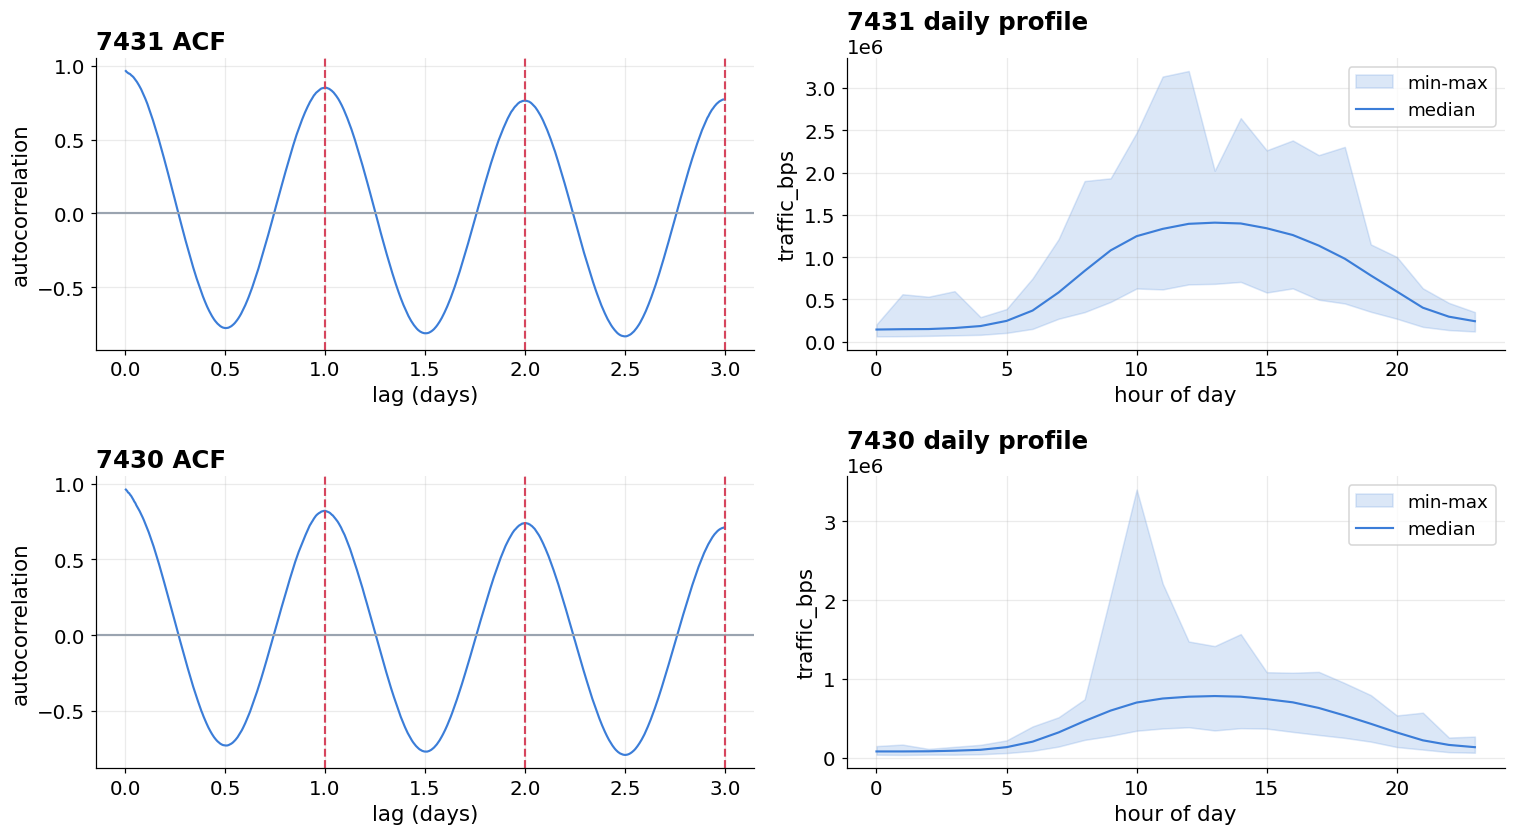

In [5]:
w, h = plt.rcParams["figure.figsize"]
fig, axes = plt.subplots(len(PORTS), 2, figsize=(w, h * 0.85 * len(PORTS)), squeeze=False)
for row, port in enumerate(PORTS):
    g = series_of(port)
    v = g["value"] - g["value"].mean()
    lags = np.arange(1, 3 * PERIOD)
    acf = np.array([v.autocorr(lag=int(k)) for k in lags])
    axes[row, 0].plot(lags / PERIOD, acf, color=C["signal"])
    axes[row, 0].axhline(0, color=C["muted"])
    for d in (1, 2, 3):
        axes[row, 0].axvline(d, color=C["alert"], ls="--")
    axes[row, 0].set(xlabel="lag (days)", ylabel="autocorrelation", title=f"{port[-4:]} ACF")

    prof = g.groupby(g["timestamp"].dt.hour)["value"].agg(["median", "min", "max"])
    axes[row, 1].fill_between(prof.index, prof["min"], prof["max"], color=C["signal"],
                              alpha=0.18, label="min-max")
    axes[row, 1].plot(prof.index, prof["median"], color=C["signal"], label="median")
    axes[row, 1].set(xlabel="hour of day", ylabel=COLUMNS[0], title=f"{port[-4:]} daily profile")
    axes[row, 1].legend()
plt.show()

The autocorrelation peaks sharply at a lag of one day and again at two and three. The daily
profile shows why: a deep night trough and a broad daytime plateau, the same shape every day.

That has a direct consequence for Lab 01's methods. On `port-id7431` the daytime plateau sits far
above the night trough, so any cutoff built from the whole history is set by the daytime, and a
night-time excursion has to clear the **daytime** bar before anyone notices. Hold that thought
until Step 8.

## Step 6 — Split and scale without leaking

The split point is an index, not a random sample. Everything before it trains, everything after
it tests, and the scaler is fitted on the training part alone. Fitting on the whole series leaks
the test period's mean and spread into training and flatters every result that follows.

In [6]:
def split_and_scale(g, train_frac=None):
    """Fit a StandardScaler on the first `train_frac` of the series, transform all of it."""
    train_frac = TRAIN_FRAC if train_frac is None else train_frac
    split = int(train_frac * len(g))
    scaler = StandardScaler().fit(g["value"].to_numpy()[:split].reshape(-1, 1))
    return split, scaler.transform(g["value"].to_numpy().reshape(-1, 1)).ravel()


for port in PORTS:
    g = series_of(port)
    split, _ = split_and_scale(g)
    print(f"{port}  split {g['timestamp'][split]}  train {split:,} / test {len(g) - split:,}  "
          f"targets in train {int(g['target'][:split].sum())}, "
          f"test {int(g['target'][split:].sum())}")

port-id7431  split 2026-02-22 00:00:00  train 6,048 / test 2,592  targets in train 36, test 0
port-id7430  split 2026-02-22 00:00:00  train 6,048 / test 2,592  targets in train 24, test 16


`port-id7431`'s event falls entirely in the training portion and `port-id7430` has 16 of its 40
anomaly samples in the test portion. That asymmetry is normal for a fixed calendar of events and
worth naming rather than engineering away.

These are unsupervised models: no label ever reaches `fit`. Training on a period containing an
event means the model saw a little contamination, which is the realistic case. Scores below are
reported over the whole month so nothing hides on either side of the split.

## Step 7 — A matrix-profile baseline

For every subsequence of length $m$, find the z-normalised Euclidean distance to its nearest
neighbour elsewhere in the series. A subsequence with no close neighbour is a **discord**: a
shape the series never repeats.

The one hyperparameter is $m$, and the rule of thumb for cyclic data is one full cycle. Two
implementation notes: the distances come from a sliding dot product computed by FFT, which is
what makes this fast enough to write by hand, and a subsequence is barred from matching its own
overlapping neighbours.

In [7]:
def rolling_stats(x, m):
    """Mean and standard deviation of every length-m window, from cumulative sums."""
    c1 = np.concatenate([[0.0], np.cumsum(x)])
    c2 = np.concatenate([[0.0], np.cumsum(x * x)])
    s1, s2 = c1[m:] - c1[:-m], c2[m:] - c2[:-m]
    mu = s1 / m
    return mu, np.sqrt(np.maximum(s2 / m - mu * mu, 1e-12))


def matrix_profile(x, m):
    """Distance from each length-m subsequence to its nearest non-overlapping neighbour.

    Returns one value per subsequence *start*, so the result is len(x) - m + 1 long. A high value
    means that shape happens nowhere else in the series.
    """
    x = np.asarray(x, dtype=float)
    k = len(x) - m + 1
    mu, sig = rolling_stats(x, m)
    n_fft = 1 << int(np.ceil(np.log2(len(x) + m)))
    fx = np.fft.rfft(x, n_fft)
    exclusion = int(np.ceil(m / 4))                 # trivial matches sit next door

    profile = np.empty(k)
    for i in range(k):
        qt = np.fft.irfft(fx * np.fft.rfft(x[i:i + m][::-1], n_fft), n_fft)[m - 1:m - 1 + k]
        corr = np.clip((qt - m * mu[i] * mu) / (m * sig[i] * sig), -1, 1)
        d = np.sqrt(np.maximum(2 * m * (1 - corr), 0))
        d[max(0, i - exclusion):min(k, i + exclusion + 1)] = np.inf
        profile[i] = d.min()
    return profile


def discord_rank(profile, target, m=None):
    """Rank of the highest-scoring subsequence whose *span* overlaps a anomaly window.

    A discord at start i covers samples i to i + m, so it hits when any anomaly sample falls in
    that span. Overlap rather than start position, because a discord beginning just before an
    event is describing that event.

    The profile has one value per subsequence start, not per sample, so a per-sample alert budget
    is meaningless on it. Rank is the honest question: how far down the discord list do you read
    before the event appears?
    """
    m = SUBSEQ if m is None else m
    t = np.asarray(target, bool)
    covers = pd.Series(t).rolling(m, min_periods=1).max().to_numpy()[m - 1:].astype(bool)
    for r, i in enumerate(np.argsort(-profile), start=1):
        if covers[i]:
            return r, int(i)
    return None, None


mp_scores = {}
for port in PORTS:
    g = series_of(port)
    prof = matrix_profile(g["value"].to_numpy(), SUBSEQ)
    mp_scores[port] = np.concatenate([prof, np.full(SUBSEQ - 1, np.nan)])
    top = int(np.argmax(prof))
    rank, at = discord_rank(prof, g["target"])
    print(f"{port}  top discord starts {g['timestamp'][top]}  distance {prof[top]:.2f}  "
          f"labels in its span: {set(g['event_label'][top:top + SUBSEQ]) - {'normal'} or 'none'}")
    print(f"{'':13}first discord whose span covers a target: rank {rank} of {len(prof):,}")

port-id7431  top discord starts 2026-02-08 00:35:00  distance 8.56  labels in its span: {'large_file_backup'}
             first discord whose span covers a target: rank 1 of 8,353


port-id7430  top discord starts 2026-02-24 11:50:00  distance 8.11  labels in its span: {'abnormal_device_sender'}
             first discord whose span covers a target: rank 1 of 8,353


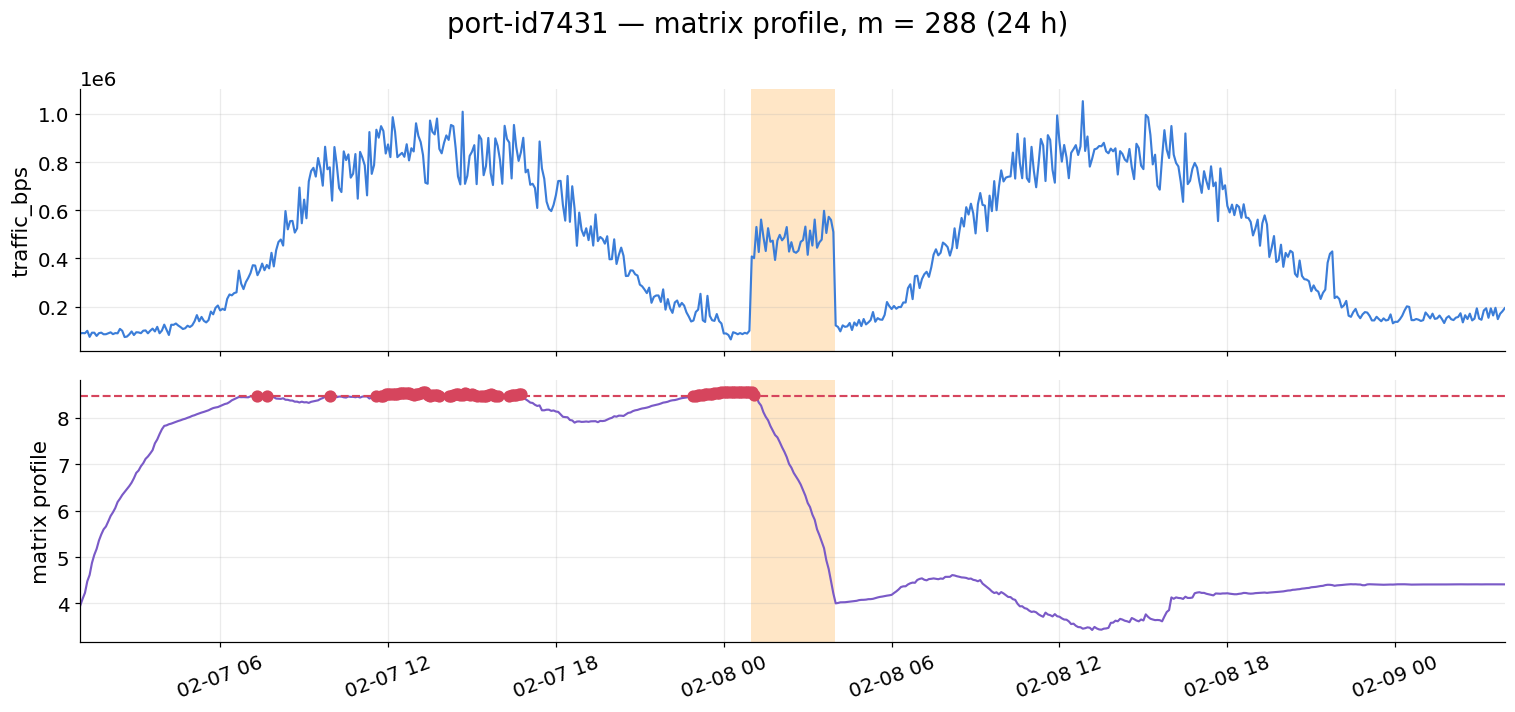

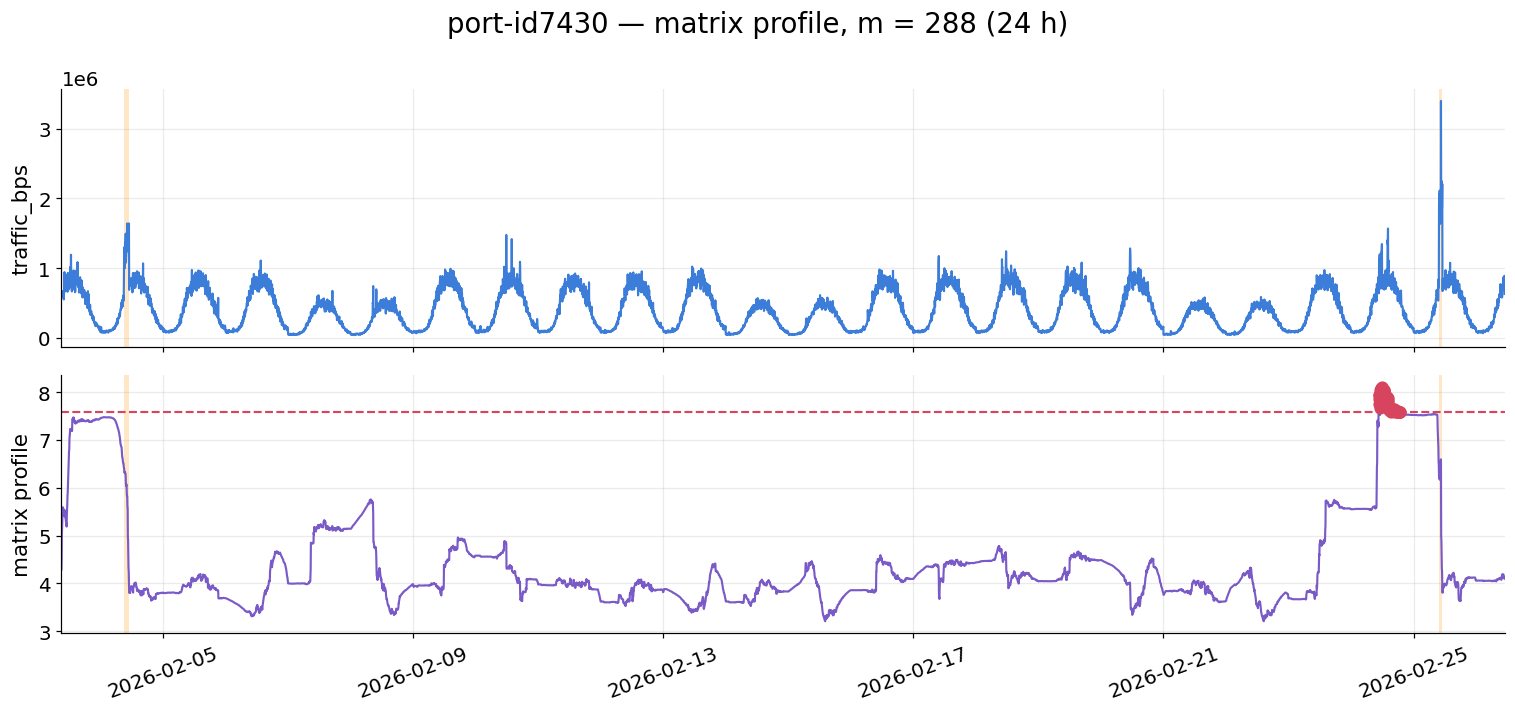

In [8]:
for port in PORTS:
    plot_series(series_of(port), {"matrix profile": mp_scores[port]},
                title=f"{port} — matrix profile, m = {SUBSEQ} "
                      f"({SUBSEQ * CADENCE / 3600:.0f} h)")

On both ports the largest discord of the month, out of more than eight thousand candidate
subsequences, spans a anomaly window. Rank 1 on each. Note that neither one *starts* inside the
event: a discord beginning shortly before an anomaly is the normal case, because the unrepeated
shape is the approach and the excursion together.

The matrix profile never saw a label and has no notion of night or day. It only knows that this
stretch of shape is unlike every other stretch, and that is what makes it a fair baseline.

### The subsequence length is the same hyperparameter as Lab 01's window

One parameter. Sweep it and read the rank of the first discord that covers an anomaly:
rank 1 means the event is the single most unusual shape in the month, and rank 2,139 means you
would read two thousand candidates before reaching it.

In [9]:
rows = []
for port in PORTS:
    g = series_of(port)
    x = g["value"].to_numpy()
    for m in (12, 36, 72, 144, 288, 576, 864):
        prof = matrix_profile(x, m)
        rank, _ = discord_rank(prof, g["target"], m)
        rows.append({"port": port[-4:], "m": m, "hours": round(m * CADENCE / 3600, 1),
                     "discord_rank": rank, "of": len(prof)})
subseq_sweep = pd.DataFrame(rows)
subseq_sweep.pivot(index=["m", "hours"], columns="port", values="discord_rank")

,port,7430,7431
m,hours,,
12,1.0,835,84
36,3.0,2139,37
72,6.0,1440,384
144,12.0,140,1
288,24.0,1,1
576,48.0,1,1
864,72.0,1,1


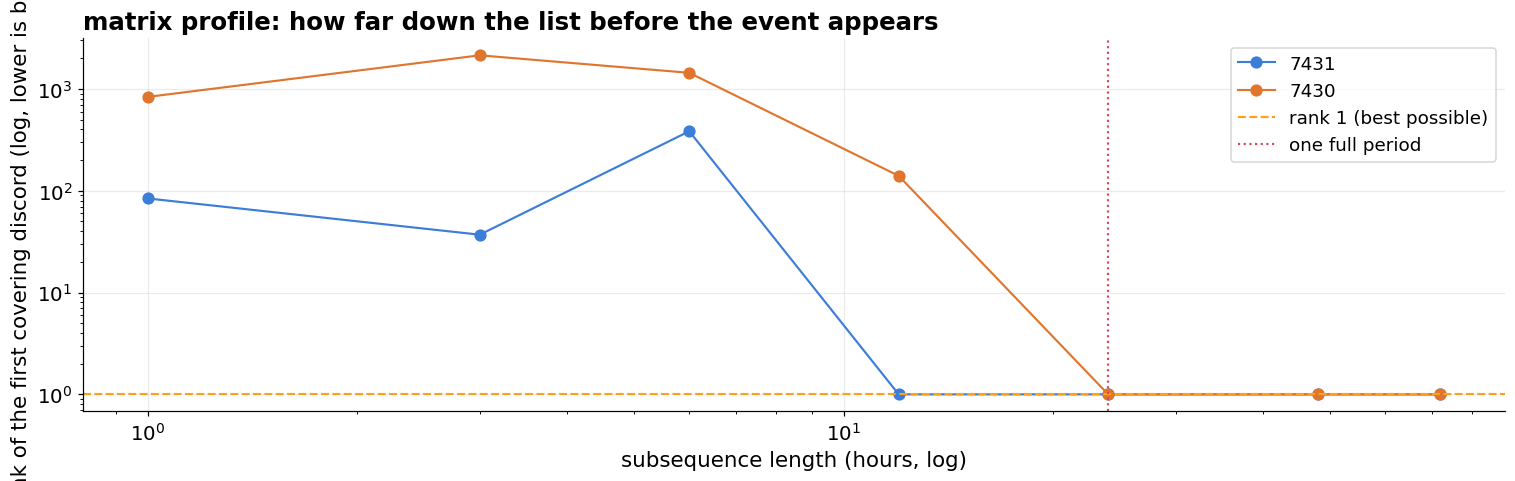

In [10]:
fig, ax = plt.subplots()
for port in PORTS:
    d = subseq_sweep[subseq_sweep["port"] == port[-4:]]
    ax.plot(d["hours"], d["discord_rank"], "-o", label=port[-4:])
ax.axhline(1, color=C["truth"], ls="--", label="rank 1 (best possible)")
ax.axvline(PERIOD * CADENCE / 3600, color=C["alert"], ls=":", label="one full period")
ax.set(xscale="log", yscale="log", xlabel="subsequence length (hours, log)",
       ylabel="rank of the first covering discord (log, lower is better)",
       title="matrix profile: how far down the list before the event appears")
ax.legend()
plt.show()

Short subsequences fail badly and for a clear reason: a one-hour or three-hour shape has close
neighbours all over thirty days, so being unusual over that span means almost nothing. At three
hours the event sits at rank 2,139 on `port-id7430`.

Both ports snap to rank 1 once the subsequence reaches a full day, and they **stay** at rank 1 at
two and three days. So on this data the "one full cycle" rule of thumb is a floor rather than a
peak, and the long end is not the failure mode it was for Lab 01's rolling baseline. The reason is
that a matrix profile is scale-free by construction: it z-normalises each subsequence before
comparing, so a longer window costs compute and resolution but does not drown the anomaly in an
average. What it does cost is precision in time, since a discord over three days tells you which
three days rather than which hour.

## Step 8 — Off-the-shelf models on raw values

Now the standard scikit-learn outlier detectors, fitted on the scaled training values, one feature
per sample. This is what "just throw an anomaly detector at it" looks like.

In [11]:
def fit_models(train, full, seed=0):
    """Fit the three detectors on `train` and score `full`. Higher score = more anomalous.

    Each library method returns higher-is-more-normal, so every score is negated. OneClassSVM is
    fitted on every tenth training row, which keeps a quadratic-time solver inside a teaching
    notebook's patience.
    """
    return {
        "IsolationForest": -IsolationForest(random_state=seed).fit(train).score_samples(full),
        "OneClassSVM": -OneClassSVM(nu=0.01, gamma="scale").fit(train[::10]).score_samples(full),
        "LOF": -LocalOutlierFactor(novelty=True).fit(train).score_samples(full),
    }


rows, raw_scores = [], {}
for port in PORTS:
    g = series_of(port)
    split, scaled = split_and_scale(g)
    X = scaled.reshape(-1, 1)
    raw_scores[port] = fit_models(X[:split], X)
    for name, s in raw_scores[port].items():
        rows.append(evaluate(f"raw {name}", port, s, g["target"]))

pd.DataFrame(rows)

,port,method,alerts,caught,of,precision
0,7431,raw IsolationForest,86,0,36,0.000
1,7431,raw OneClassSVM,87,0,36,0.000
2,7431,raw LOF,87,0,36,0.000
3,7430,raw IsolationForest,86,39,40,0.453
4,7430,raw OneClassSVM,87,36,40,0.414
5,7430,raw LOF,87,21,40,0.241


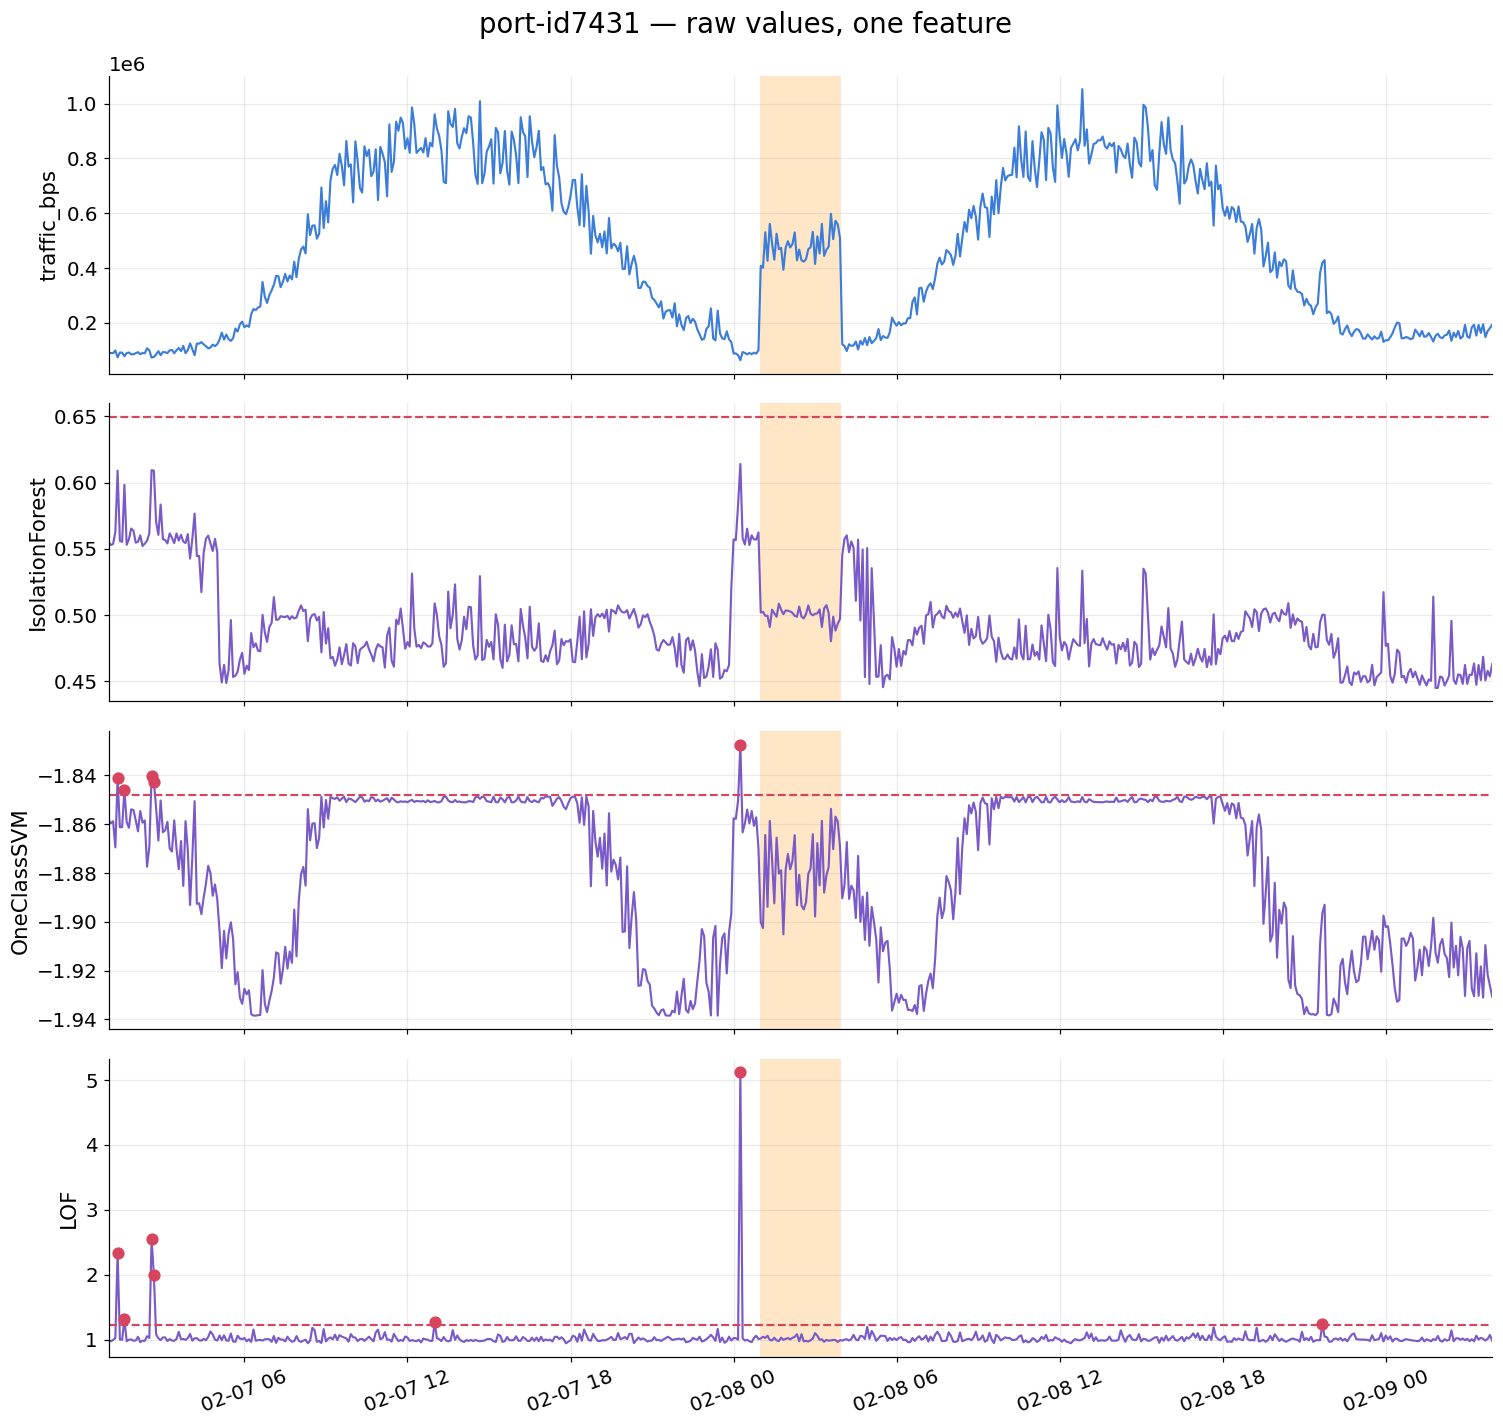

In [12]:
plot_series(series_of(PORTS[0]), raw_scores[PORTS[0]],
            title=f"{PORTS[0]} — raw values, one feature")

On `port-id7430` the three models do fine: its anomalies are a daytime surge, extreme in absolute
terms, and a global model sees them.

On `port-id7431` all three catch **zero**. Look at the top panel and the reason is plain. The bulk
transfer runs at roughly the level of an ordinary weekday afternoon. It happens at one in the
morning, when the port is normally near idle, and that is the entire anomaly. A model given one
number per sample and no clock cannot express "high for 1 a.m."; it only knows "high", and this is
not high.

The rest of the lab is about giving the model the clock.

## Step 9 — Remove the seasonality

Decompose the series additively:

$$x_t = \mathrm{trend}_t + \mathrm{season}_t + \mathrm{resid}_t$$

The trend is a centred rolling mean over one full cycle, which averages the cycle away. The season
is the typical shape of a day, taken as the **median** of the detrended values at each position in
the cycle, so one anomalous day does not redraw the profile. What is left is the residual, and
that is what gets scored.

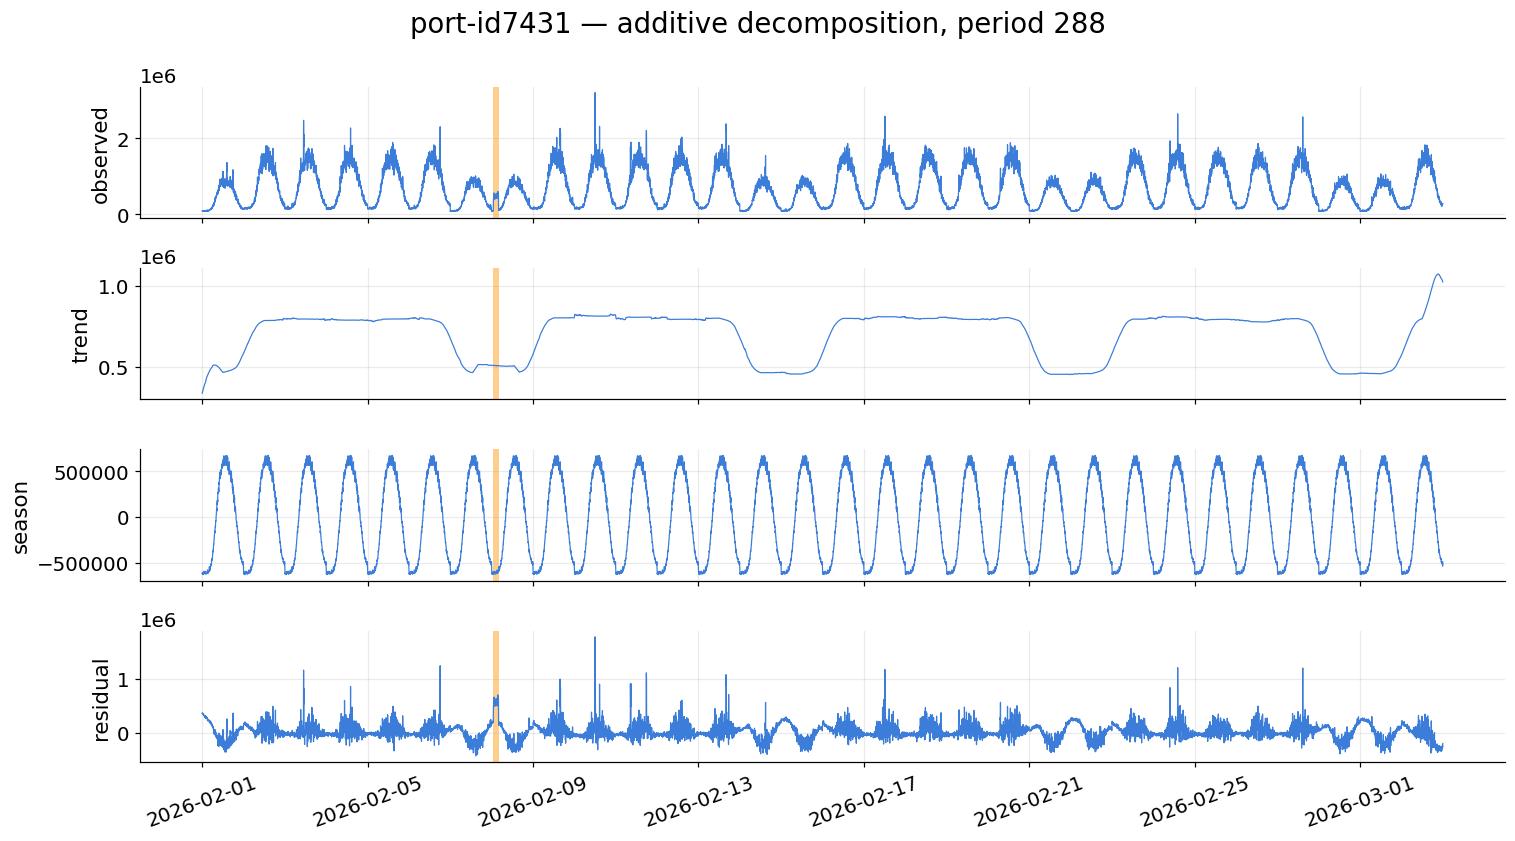

In [13]:
def decompose(x, period=None):
    """Additive trend / season / residual. A median seasonal profile resists contamination."""
    period = PERIOD if period is None else period
    s = pd.Series(np.asarray(x, dtype=float))
    trend = s.rolling(period, center=True, min_periods=period // 2).mean()
    detrended = s - trend
    season = detrended.groupby(np.arange(len(s)) % period).transform("median")
    return trend.to_numpy(), season.to_numpy(), (s - trend - season).to_numpy()


port = PORTS[0]
g = series_of(port)
trend, season, resid = decompose(g["value"])

w, h = plt.rcParams["figure.figsize"]
fig, axes = plt.subplots(4, 1, figsize=(w, h * 1.7), sharex=True)
for ax, (name, v) in zip(axes, [("observed", g["value"].to_numpy()), ("trend", trend),
                                ("season", season), ("residual", resid)]):
    ax.plot(g["timestamp"], v, lw=0.8, color=C["signal"])
    ax.set_ylabel(name)
for ax in axes:
    for a, b in target_runs(g):
        ax.axvspan(a, b, color=C["truth"], alpha=0.5, lw=0)
axes[-1].tick_params(axis="x", labelrotation=20)
fig.suptitle(f"{port} — additive decomposition, period {PERIOD}")
plt.show()

At full-month scale the shaded sliver is too narrow to read. Zoom in, and put a number on what the
decomposition did.

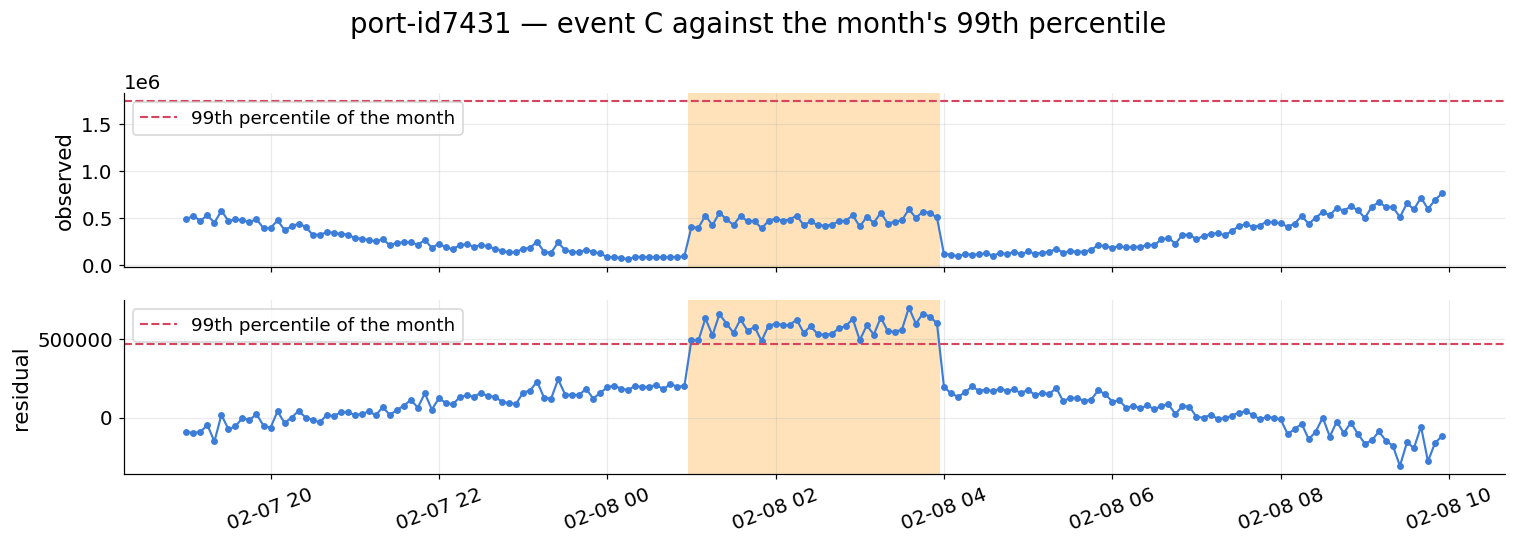

observed  event peak sits at the 49.3% percentile, 4,377 samples are higher, 0/36 above the 99th
residual  event peak sits at the 99.7% percentile, 29 samples are higher, 36/36 above the 99th


In [14]:
mask = g["target"].to_numpy()
zoom = (g.loc[mask, "timestamp"].min() - pd.Timedelta(hours=6),
        g.loc[mask, "timestamp"].max() + pd.Timedelta(hours=6))
view = g["timestamp"].between(*zoom).to_numpy()

w, h = plt.rcParams["figure.figsize"]
fig, axes = plt.subplots(2, 1, figsize=(w, h * 1.1), sharex=True)
for ax, (name, v) in zip(axes, [("observed", g["value"].to_numpy()), ("residual", resid)]):
    ax.plot(g.loc[view, "timestamp"], pd.Series(v)[view], marker=".", color=C["signal"])
    ax.axhline(np.nanquantile(v, 0.99), color=C["alert"], ls="--",
               label="99th percentile of the month")
    for a, b in target_runs(g):
        ax.axvspan(a, b, color=C["truth"], alpha=0.3, lw=0)
    ax.set_ylabel(name)
    ax.legend(loc="upper left")
axes[-1].tick_params(axis="x", labelrotation=20)
fig.suptitle(f"{port} — event C against the month's 99th percentile")
plt.show()

for name, v in [("observed", g["value"].to_numpy()), ("residual", resid)]:
    v = pd.Series(v)
    print(f"{name:9} event peak sits at the {v.rank(pct=True)[mask].max():.1%} percentile, "
          f"{int((v > v[mask].max()).sum()):,} samples are higher, "
          f"{int((v[mask] > v.quantile(0.99)).sum())}/{int(mask.sum())} above the 99th")

The two lines say it exactly. In the observed series the event's peak sits at the 49th percentile
of the month, with 4,377 ordinary samples above it, and not one of its 36 samples clears the 99th
percentile. In the residual all 36 clear it, and the peak moves from the 49th percentile to the
99.7th.

The data did not change. Subtracting the expected shape of a day converted a contextual anomaly
into an absolute one. Refit the same three models on the residual, changing nothing else.

In [15]:
resid_scores = {}
for port in PORTS:
    g = series_of(port)
    r = np.nan_to_num(decompose(g["value"])[2], nan=0.0)
    split = int(TRAIN_FRAC * len(g))
    X = StandardScaler().fit(r[:split].reshape(-1, 1)).transform(r.reshape(-1, 1))
    resid_scores[port] = fit_models(X[:split], X)
    for name, s in resid_scores[port].items():
        rows.append(evaluate(f"deseasonalised {name}", port, s, g["target"]))

pd.DataFrame(rows).query("method.str.contains('raw|deseasonalised')")

,port,method,alerts,caught,of,precision
0,7431,raw IsolationForest,86,0,36,0.000
1,7431,raw OneClassSVM,87,0,36,0.000
2,7431,raw LOF,87,0,36,0.000
3,7430,raw IsolationForest,86,39,40,0.453
4,7430,raw OneClassSVM,87,36,40,0.414
5,7430,raw LOF,87,21,40,0.241
6,7431,deseasonalised IsolationForest,87,23,36,0.264
7,7431,deseasonalised OneClassSVM,87,4,36,0.046
8,7431,deseasonalised LOF,87,5,36,0.057
9,7430,deseasonalised IsolationForest,85,40,40,0.471


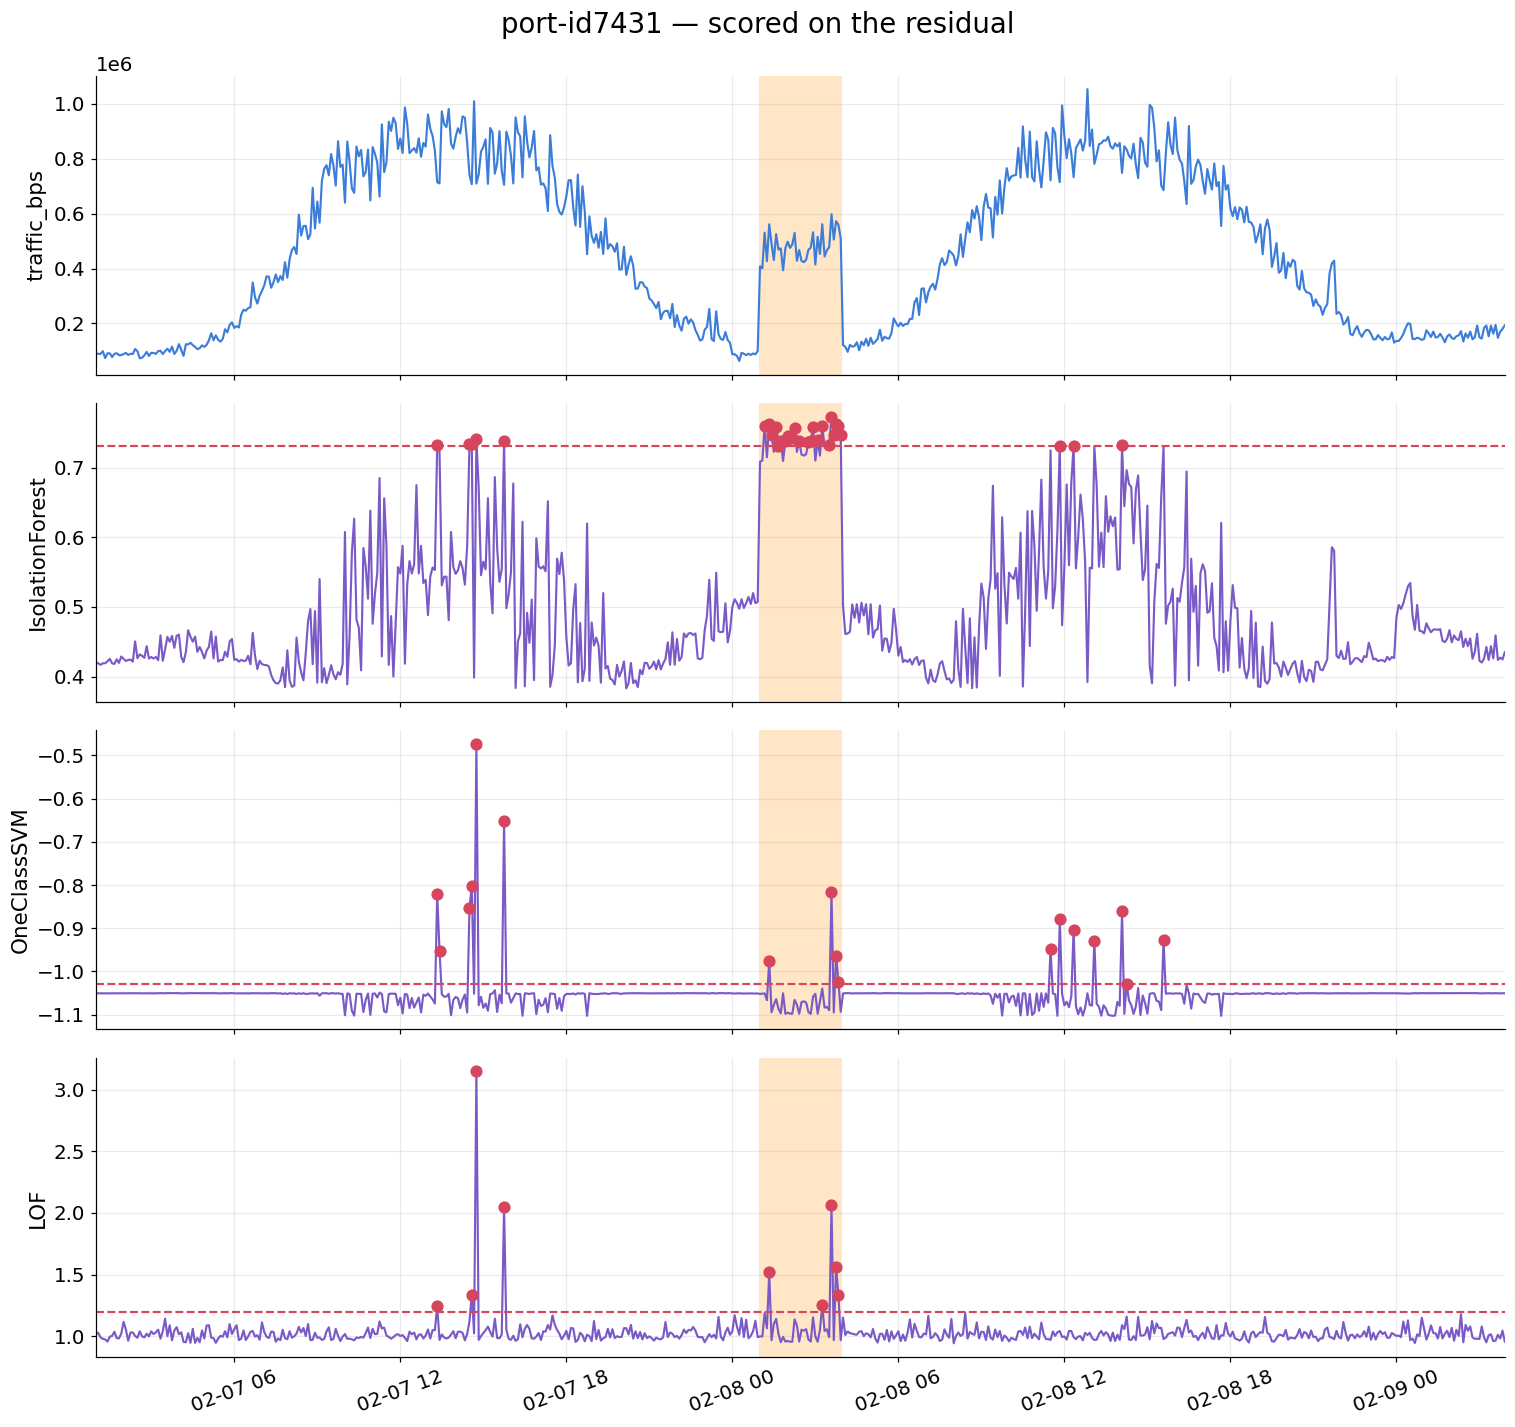

In [16]:
plot_series(series_of(PORTS[0]), resid_scores[PORTS[0]],
            title=f"{PORTS[0]} — scored on the residual")

On `port-id7431`, `IsolationForest` goes from 0 of 36 to 23. The other two move from 0 to 4 and 5,
which is a detection rather than a fix: a single global cut on the residual still struggles when
the residual's own spread is dominated by daytime noise.

On `port-id7430` nothing much changes, because its anomalies were already absolute. That is the
expected result and worth seeing. Deseasonalising is not a general improvement, it is a targeted
one, and it costs a parameter you now have to keep correct.

## Step 10 — Sliding windows

The other way to give a model context: stop feeding it one number and feed it the last `N_INPUT`
numbers as a vector. A sample is then judged by the shape it sits in rather than by its own height.

```
value:  [10, 20, 30, 40, 50, 60, ...]
rows:   [10, 20, 30]
            [20, 30, 40]
                [30, 40, 50]
```

In [17]:
def sliding_windows(x, n_input=None):
    """Rows of `n_input` consecutive values. Row i ends at sample i + n_input - 1."""
    n_input = N_INPUT if n_input is None else n_input
    return np.lib.stride_tricks.sliding_window_view(np.asarray(x, dtype=float), n_input)


window_scores = {}
for port in PORTS:
    g = series_of(port)
    W = sliding_windows(g["value"])
    split = int(TRAIN_FRAC * len(W))
    Xw = StandardScaler().fit(W[:split]).transform(W)
    scored = fit_models(Xw[:split], Xw)
    # a window's score belongs to the sample it ends on, so pad the leading samples
    window_scores[port] = {k: np.concatenate([np.full(N_INPUT - 1, np.nan), v])
                           for k, v in scored.items()}
    for name, s in window_scores[port].items():
        rows.append(evaluate(f"window{N_INPUT} {name}", port, s, g["target"]))

pd.DataFrame(rows).query("method.str.contains('window')")

,port,method,alerts,caught,of,precision
12,7431,window36 IsolationForest,87,15,36,0.172
13,7431,window36 OneClassSVM,87,0,36,0.000
14,7431,window36 LOF,87,31,36,0.356
15,7430,window36 IsolationForest,87,28,40,0.322
16,7430,window36 OneClassSVM,87,21,40,0.241
17,7430,window36 LOF,87,10,40,0.115


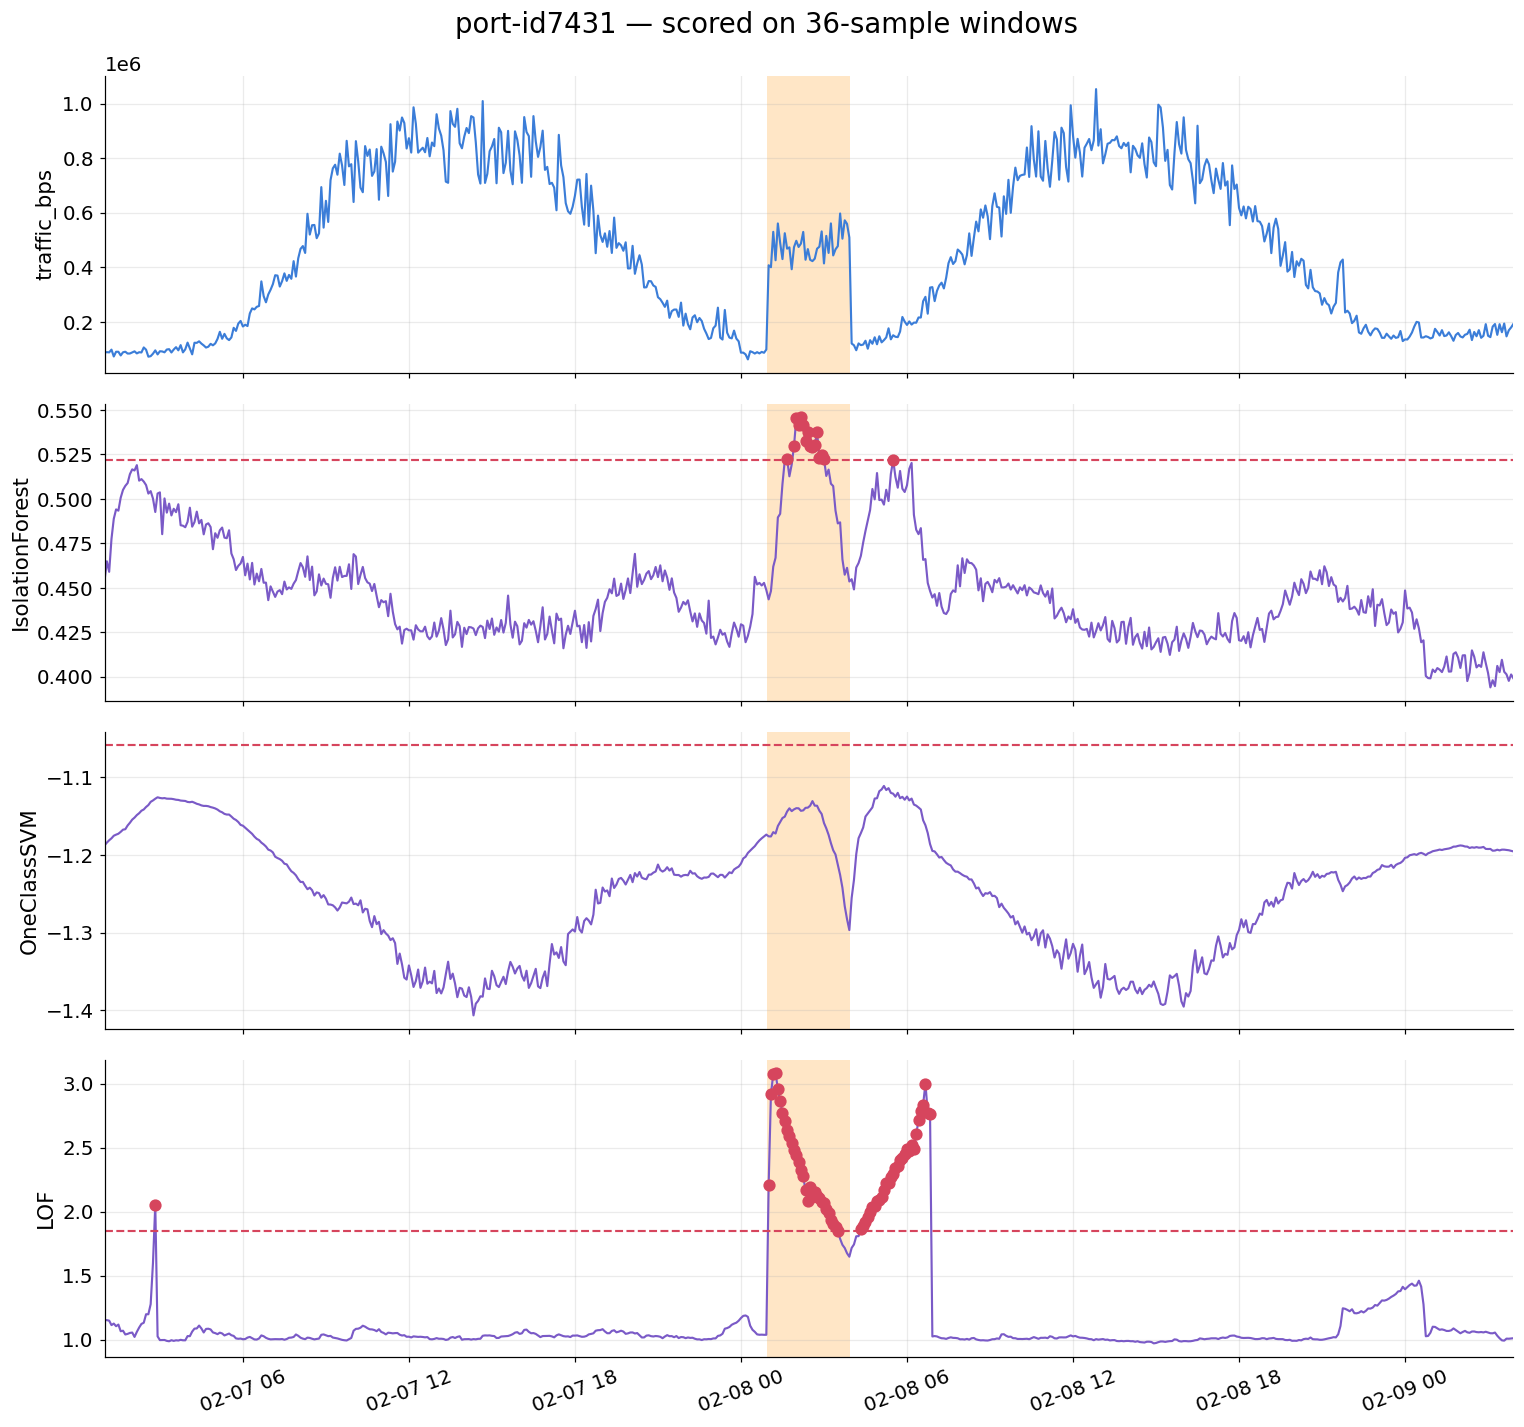

In [18]:
plot_series(series_of(PORTS[0]), window_scores[PORTS[0]],
            title=f"{PORTS[0]} — scored on {N_INPUT}-sample windows")

On `port-id7431`, `LocalOutlierFactor` goes from 0 of 36 to 31, the best result any method reaches
on that event, and it got there without computing a seasonal profile at all. That follows from
what LOF measures. It scores a point by the density of its neighbours, and in 36 dimensions a
3 a.m. ramp has no neighbours; in one dimension it sat in the middle of a crowded axis.

The same change makes things worse on `port-id7430`, where LOF drops from 21 to 10 and
`IsolationForest` from 39 to 28. Windowing spends its sensitivity on shape, and an event already
obvious by height gets diluted across 36 dimensions.

So the two remedies are not interchangeable. The decomposition subtracts the expected shape, the
window lets the model compare shapes. Which one wins depends on the anomaly.

### Sweep `N_INPUT`, the same hyperparameter again

Lab 01 swept a baseline window and found failure at both ends. A sliding-window length has the
same shape of problem for different reasons: too short and the window carries no context, and as
it approaches `PERIOD` every window becomes a whole day and they all look alike.

In [19]:
rows_w = []
for port in PORTS:
    g = series_of(port)
    for n in (6, 12, 24, 36, 72, 144, 288):
        W = sliding_windows(g["value"], n)
        split = int(TRAIN_FRAC * len(W))
        Xw = StandardScaler().fit(W[:split]).transform(W)
        for name, s in fit_models(Xw[:split], Xw).items():
            padded = np.concatenate([np.full(n - 1, np.nan), s])
            r = evaluate(name, port, padded, g["target"])
            rows_w.append({"port": port[-4:], "model": name, "n_input": n,
                           "hours": round(n * CADENCE / 3600, 1),
                           "caught": r["caught"], "of": r["of"]})
window_sweep = pd.DataFrame(rows_w)
window_sweep.pivot_table(index=["n_input", "hours"], columns=["port", "model"], values="caught")

port                     7430                              7431                  
model         IsolationForest   LOF OneClassSVM IsolationForest   LOF OneClassSVM
n_input hours                                                                    
6       0.5              37.0  13.0        26.0             0.0   5.0         0.0
12      1.0              35.0  16.0        32.0             0.0  11.0         0.0
24      2.0              31.0  14.0        32.0            11.0  22.0         0.0
36      3.0              28.0  10.0        21.0            15.0  31.0         0.0
72      6.0              13.0   7.0        15.0             0.0  32.0         0.0
144     12.0              0.0  11.0         0.0             0.0   0.0         0.0
288     24.0             17.0  10.0         4.0             0.0   0.0         0.0

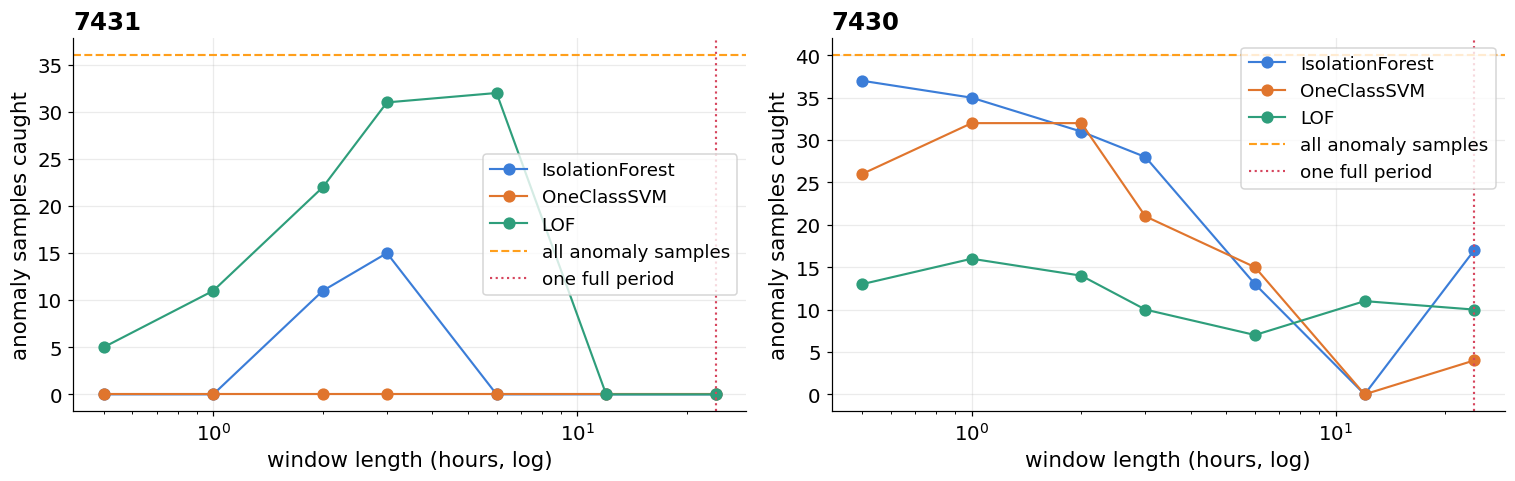

In [20]:
w, h = plt.rcParams["figure.figsize"]
fig, axes = plt.subplots(1, len(PORTS), figsize=(w, h), sharey=False)
for ax, port in zip(np.atleast_1d(axes), PORTS):
    d = window_sweep[window_sweep["port"] == port[-4:]]
    for model, c in [("IsolationForest", C["signal"]), ("OneClassSVM", C["baseline"]),
                     ("LOF", C["peer"])]:
        k = d[d["model"] == model]
        ax.plot(k["hours"], k["caught"], "-o", color=c, label=model)
    ax.axhline(d["of"].max(), color=C["truth"], ls="--", label="all anomaly samples")
    ax.axvline(PERIOD * CADENCE / 3600, color=C["alert"], ls=":", label="one full period")
    ax.set(xscale="log", xlabel="window length (hours, log)", ylabel="anomaly samples caught",
           title=port[-4:])
    ax.legend()
plt.show()

The two ports disagree, and the disagreement is the point.

On `port-id7431`, whose event is contextual, there is a clear interior optimum. `LOF` climbs 5,
11, 22, 31, 32 as the window grows from 30 minutes to 6 hours, then falls to zero at 12 hours and
beyond. `IsolationForest` peaks at 3 hours. Both ends fail: too short and the window carries no
context, and once the window approaches a full period every row contains most of a day and they
all look alike, so nothing is unusual any more.

On `port-id7430`, whose events are absolute, the shortest window is the best one and every
increase costs accuracy. There is nothing contextual to recover, so the extra dimensions only
dilute a signal that was already visible in one.

`OneClassSVM` catches nothing on `port-id7431` at any window length. A single global boundary in
36 dimensions, fitted with `nu=0.01` on a training set that contains the event, is not a shape
detector. Compare that against `LOF`'s 32: the model matters as much as the framing, and neither
alone is enough.

## Step 11 — Change points: did the system move to a new level?

Everything so far asks whether a sample is far from a baseline. A change point asks a different
question: did the data-generating process change? A deployment that moves memory from 40% to 65%
produces no outlier at all, and every point-wise detector stays silent while the system is
permanently different.

Two standard approaches, both cheap.

**Two-window score.** Compare the mean of the window before time $t$ with the mean of the window
after it:

$$\mathrm{score}_t = \left| \mathrm{mean}(x_{t-w \ldots t}) - \mathrm{mean}(x_{t \ldots t+w}) \right|$$

That form uses the future, so it is an offline method. Online you compare an older reference
window against a recent detection window and accept the delay.

**CUSUM.** Accumulate small deviations instead of thresholding each one:

$$S_t = \max(0,\; S_{t-1} + z_t - k)$$

A persistent shift too small to trip a per-sample cutoff adds up until $S_t$ crosses a limit. `k`
is the slack, the size of a deviation you are willing to ignore, and `h` is the limit.

In [21]:
def two_window(x, w, online=False):
    """|mean(previous w) - mean(next w)| at every point.

    online=True compares two windows that both sit in the past, separated by a gap of w, which is
    what a live detector can actually compute. The offline form is centred on t and peaks exactly
    at the change; the online form peaks w samples later.
    """
    s = pd.Series(np.asarray(x, dtype=float))
    before = s.rolling(w, min_periods=w // 2).mean()
    after = before.shift(-w) if not online else before.shift(w)
    return (before - after).abs() if online else (after - before).abs()


def cusum(z, k=1.5, h=5.0):
    """One-sided CUSUM on a standardised series, resetting after each alarm.

    Returns (statistic, alarm mask). Without the reset the statistic ratchets upward and every
    later sample inherits the first excursion.

    The returned statistic holds the value at the moment of crossing rather than the post-reset
    zero, so a plotted peak actually touches the limit line and the alarm marker sits on it.
    """
    z = np.asarray(z, dtype=float)
    S = np.zeros(len(z))
    alarm = np.zeros(len(z), bool)
    run = 0.0
    for t in range(1, len(z)):
        run = max(0.0, run + z[t] - k)
        S[t] = run
        if run > h:
            alarm[t] = True
            run = 0.0
    return S, alarm


port = PORTS[1]                      # the port whose calendar entry claims a level shift
g = series_of(port)
level = g["value"].rolling(PERIOD, min_periods=PERIOD // 2).mean()     # for the display panel
# Applied to the raw series, not to `level`: `level` is already a rolling mean, and running a
# second one over it would smooth the very step the score exists to find.
tw = two_window(g["value"], PERIOD, online=True)

resid = np.nan_to_num(decompose(g["value"])[2], nan=0.0)
train = resid[:int(TRAIN_FRAC * len(resid))]
z = (resid - train.mean()) / train.std()
S, alarm = cusum(z, k=1.5, h=5.0)

peak = int(tw.idxmax())
print(f"{port}")
print(f"  two-window peak at {g['timestamp'][peak]} "
      f"({g['timestamp'][peak].day_name()}, label {g['event_label'][peak]})")
# every local maximum in the top decile, kept 12 h apart, with the weekday it fell on
v = np.nan_to_num(tw.to_numpy())
kept = []
for i in np.argsort(-v):
    if v[i] < tw.quantile(0.90):
        break
    if all(abs(i - j) > PERIOD // 2 for j in kept):
        kept.append(int(i))
print("  every top-decile peak:",
      ", ".join(f"{g['timestamp'][i]:%m-%d} {g['timestamp'][i].day_name()[:3]}"
                for i in sorted(kept)))
print(f"  CUSUM: {alarm.sum()} alarms, {int((alarm & g['target'].to_numpy()).sum())} inside a "
      f"anomaly window, {(alarm & ~g['target'].to_numpy()).sum() / DAYS:.2f} per day outside")

port-id7430
  two-window peak at 2026-02-14 23:55:00 (Saturday, label normal)
  every top-decile peak: 02-02 Mon, 02-07 Sat, 02-09 Mon, 02-14 Sat, 02-16 Mon, 02-21 Sat, 02-23 Mon, 02-28 Sat, 03-02 Mon
  CUSUM: 49 alarms, 31 inside a anomaly window, 0.60 per day outside


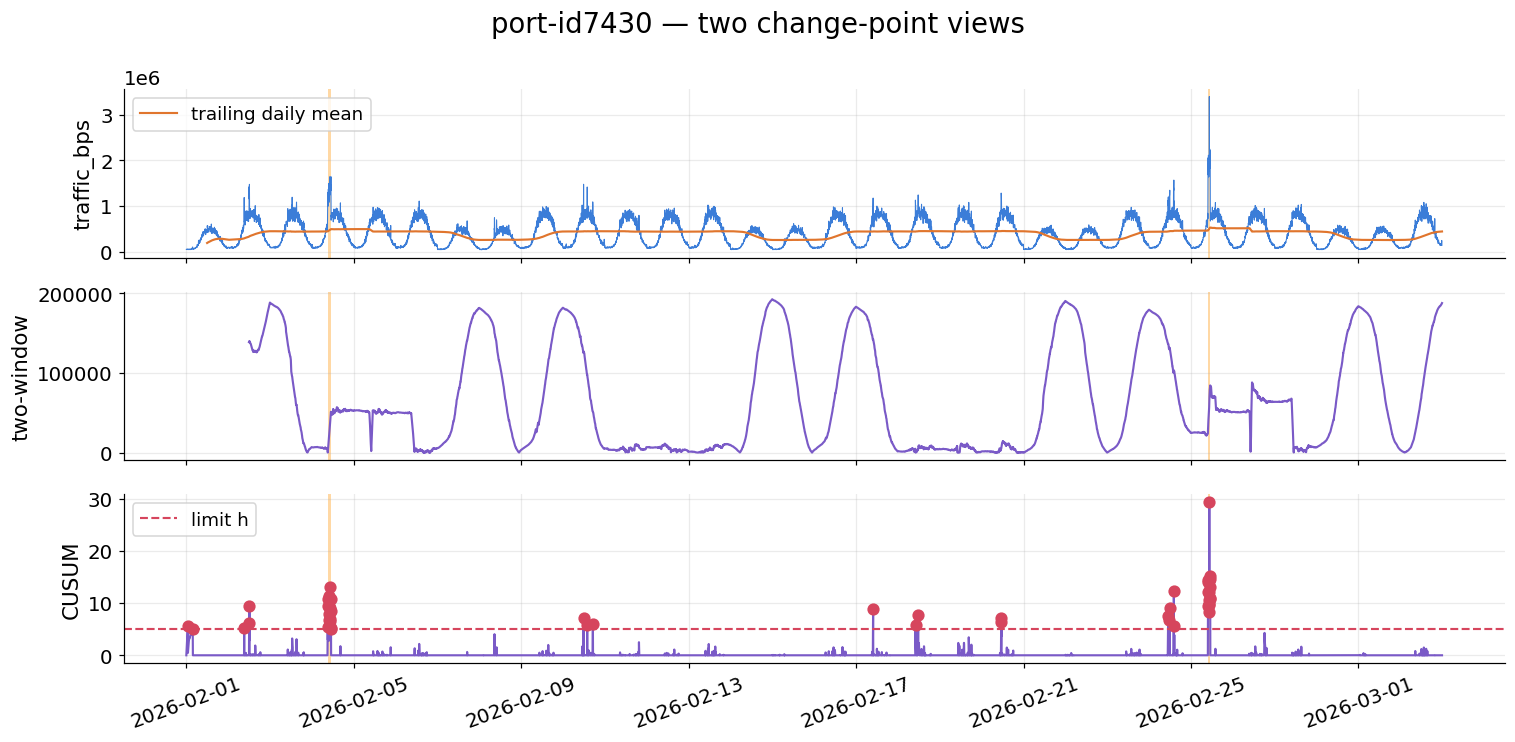

In [22]:
w, h = plt.rcParams["figure.figsize"]
fig, axes = plt.subplots(3, 1, figsize=(w, h * 1.5), sharex=True)
axes[0].plot(g["timestamp"], g["value"], lw=0.7, color=C["signal"])
axes[0].plot(g["timestamp"], level, color=C["baseline"], label="trailing daily mean")
axes[0].set_ylabel("traffic_bps")
axes[0].legend(loc="upper left")

axes[1].plot(g["timestamp"], tw, color=C["score"])
axes[1].set_ylabel("two-window")

axes[2].plot(g["timestamp"], S, color=C["score"])
axes[2].axhline(5.0, color=C["alert"], ls="--", label="limit h")
axes[2].scatter(g.loc[alarm, "timestamp"], S[alarm], color=C["alert"], zorder=5)
axes[2].set_ylabel("CUSUM")
axes[2].legend(loc="upper left")

for ax in axes:
    for a, b in target_runs(g):
        ax.axvspan(a, b, color=C["truth"], alpha=0.4, lw=0)
axes[-1].tick_params(axis="x", labelrotation=20)
fig.suptitle(f"{port} — two change-point views")
plt.show()

### A change point is not an incident

The two-window trace does not peak on any anomaly. Print the top-decile peaks with the day
they fell on and the pattern is total: every one is a Saturday or a Monday, at 23:55. Those are
the two boundaries of the weekend, the biggest genuine level changes in the month, and every one
of them is expected.

CUSUM, run on the deseasonalised residual where the weekly cycle is already removed, behaves
differently: 49 alarms, 31 of them inside a anomaly window, 0.60 stray alarms per day. Accumulating
small deviations finds a two-hour surge that no single sample would have tripped, which is exactly
the division of labour the method exists for: single-point rules for large spikes, cumulative
methods for sustained small offsets.

That contrast is the lesson, not a failure. `change_calendar.csv` describes CH-02 on this port as a
permanent level shift upward, and the data disagrees: the weekday 09:00-11:00 mean by week is
8.2e5, 6.9e5, 7.1e5, 8.6e5, 6.8e5. Noise, not a step. So the only real change points here are
calendar-driven ones that nobody should be paged for.

A detected change point is an **entry point for investigation**, not a verdict. Correlate it with
deployments, change tickets and maintenance announcements first. If the new state is fine,
re-estimate the baseline; if it is unexpected and touches an SLO, escalate.

## Step 12 — EWMA, and why a control limit is not optional

CUSUM accumulates. EWMA weights: it keeps a geometrically decaying mean of everything seen so far,

$$s_t = \lambda z_t + (1 - \lambda) s_{t-1}$$

so `lambda` sets the memory, roughly (2 - lambda) / lambda samples. A small value is a long memory
and a smooth statistic; a large one approaches the raw score.

The part that catches people out is the scale. The EWMA of a standardised series has standard
deviation sqrt(lambda / (2 - lambda)), which at 0.2 is 0.33. Compare that statistic against a
threshold of 4 and it can never fire, because it is a third of the size of the thing the threshold
was written for. Divide by the control limit and every lambda lands back on the same axis, where 4
means what it meant everywhere else.

In [23]:
def ewma_score(z, lam=0.2, L=1.0):
    """Geometrically weighted mean of a standardised series, rescaled onto the sigma axis.

    Dividing by L * sqrt(lam / (2 - lam)) is what lets one threshold serve every lam. Skip it and
    the statistic is a fraction of the raw score, so nothing ever crosses a cutoff of 4.
    """
    z = pd.Series(np.asarray(z, dtype=float)).fillna(0.0)
    s = z.ewm(alpha=lam, adjust=False).mean()
    limit = L * np.sqrt(lam / (2 - lam))
    return s / limit


port = PORTS[1]
g = series_of(port=port, col=COLUMNS[0], data=df)
resid = np.nan_to_num(decompose(x=g["value"], period=PERIOD)[2], nan=0.0)
train = resid[:int(TRAIN_FRAC * len(resid))]
z = (resid - train.mean()) / train.std()

rows_e = []
for lam in (0.05, 0.1, 0.2, 0.4, 0.8):
    raw = pd.Series(z).ewm(alpha=lam, adjust=False).mean()
    scaled = ewma_score(z=z, lam=lam, L=1.0)
    limit = np.sqrt(lam / (2 - lam))
    rows_e.append({"lam": lam, "memory_samples": round((2 - lam) / lam, 1),
                   "control_limit": round(float(limit), 4),
                   "implied_threshold_if_unscaled": round(4.0 / float(limit), 2),
                   "raw alerts > 4": int((raw.abs() > 4).sum()),
                   "rescaled alerts > 4": int((scaled.abs() > 4).sum())})
pd.DataFrame(rows_e)

,lam,memory_samples,control_limit,implied_threshold_if_unscaled,raw alerts > 4,rescaled alerts > 4
0,0.05,39.0,0.1601,24.98,26,2202
1,0.10,19.0,0.2294,17.44,40,1687
2,0.20,9.0,0.3333,12.00,40,807
3,0.40,4.0,0.5000,8.00,51,143
4,0.80,1.5,0.8165,4.90,63,75


`implied_threshold_if_unscaled` is the column to read. Comparing an unscaled EWMA against 4 is the
same as comparing the underlying z-score against 4 divided by the control limit: 12.0 at
lambda = 0.2, 17.4 at 0.1, and 25.0 at 0.05. Nothing errors and nothing warns. The detector is
simply running at a threshold three to six times stricter than the one written in the config, and
the two alert-count columns show the cost.

Two consequences follow. Omitting the rescale silently couples sensitivity to memory length, so
tuning lambda for smoothness also retunes the threshold, which is the coupling the control limit
exists to break. And on this residual the raw statistic still fires, because the residual reaches
|z| far above 12 during an anomaly; on a quieter signal the same omission produces a detector that
never speaks at all. That an error is survivable on one series and fatal on another is what makes it
worth a cell rather than a comment.

Now run all three accumulating detectors on the same series.

In [24]:
S_cusum, alarm_cusum = cusum(z=z, k=0.5, h=5.0)
ew = ewma_score(z=z, lam=0.2, L=1.0)
tw = two_window(x=g["value"], w=PERIOD, online=True)

acc = {
    "CUSUM k=0.5 h=5.0": pd.Series(alarm_cusum),
    "EWMA lam=0.2 over 4": (ew.abs() > 4),
    "two-window over q99": (tw > tw.quantile(0.99)).fillna(False),
}
tgt = g["target"].to_numpy()
rows_acc = []
for name, a in acc.items():
    m = a.reindex(range(len(g)), fill_value=False).to_numpy()
    rows_acc.append({"detector": name, "alerts": int(m.sum()),
                     "hits_in_anomaly": int((m & tgt).sum()),
                     "precision": round(float((m & tgt).sum() / max(m.sum(), 1)), 3),
                     "alerts_per_day": round(float((m & ~tgt).sum()) / DAYS, 2)})
pd.DataFrame(rows_acc)

,detector,alerts,hits_in_anomaly,precision,alerts_per_day
0,CUSUM k=0.5 h=5.0,150,34,0.227,3.87
1,EWMA lam=0.2 over 4,807,39,0.048,25.60
2,two-window over q99,83,0,0.000,2.77


Two structural notes worth more than the numbers.

**CUSUM must run with no confirmation layer.** It resets to zero the moment it signals, so its
statistic sits above the limit for exactly one sample by construction. Requiring two in a row
charges the same detector twice for a property it already has, and silences it completely. The
general rule: a confirmation layer exists to give a memoryless score some persistence, so it is
redundant on any statistic that already carries state.

**EWMA is late in both directions.** It peaks after the raw score does and decays more slowly, so it
buys smoothness with delay at the start and with a tail of alerts after the anomaly is over.

## Step 13 — Composing many features, and the failure hiding inside it

Scoring one column at a time answers "is this feature unusual". Operations wants "is this port
unusual", which is a composition question. The cheapest composition is the maximum absolute z across
features. Max rather than mean, because a mean dilutes: one feature screaming and six quiet averages
down to mild, while max lets any single feature clear the cutoff alone. What max discards is
agreement, since it cannot tell one feature at 12 from six features at 12.

The interesting part is what happens when the six degenerate features join in.

In [25]:
def robust_z_matrix(data=df, cols=None, ports=None, window=None, cap=50.0, floor_frac=0.05):
    """Absolute robust z for every column, per port, capped. Same length as data.

    The cap and the floor are numerical guards: without the floor a quiet stretch drives the MAD
    toward zero and any deviation scores in the thousands. Both are named here rather than buried,
    because the next cell is about what they do to the score's own distribution.
    """
    cols = SCORABLE if cols is None else cols
    ports = PORTS if ports is None else ports
    window = WINDOW if window is None else window
    mp = max(3, window // 3)
    out = {}
    for col in cols:
        z = pd.Series(np.nan, index=data.index, dtype=float)
        for pid in ports:
            gi = data.index[data["port_id"] == pid]
            prev = data.loc[gi, col].shift(1)
            c = prev.rolling(window, min_periods=mp).median()
            sc = (prev - c).abs().rolling(window, min_periods=mp).median() * 1.4826
            whole = data.loc[gi, col].to_numpy(dtype=float)
            fl = max(floor_frac * 1.4826 * np.median(np.abs(whole - np.median(whole))), 1e-12)
            z.loc[gi] = ((data.loc[gi, col] - c) / sc.fillna(fl).clip(lower=fl)).clip(-cap, cap)
        out[col] = z.abs()
    return pd.DataFrame(out, index=data.index)


CAP = 50.0            # the score cap, and the whole subject of this step
WINDOW = 12           # rolling window in samples, one hour. Lab 01 Step 9 is why
z_scorable = robust_z_matrix(data=df, cols=SCORABLE, ports=PORTS, window=WINDOW,
                             cap=CAP, floor_frac=0.05)
z_all = robust_z_matrix(data=df, cols=FEATURES, ports=PORTS, window=WINDOW,
                        cap=CAP, floor_frac=0.05)
score_scorable = z_scorable.max(axis=1)
score_all = z_all.max(axis=1)

for name, sc in [(f"max abs z over {len(SCORABLE)} scorable", score_scorable),
                 (f"max abs z over all {len(FEATURES)}", score_all)]:
    at_cap = float((sc >= CAP - 1e-9).mean())
    print(f"{name:32} at the cap {at_cap:7.2%} | q0.99 {np.nanquantile(sc.dropna(), 0.99):8.3f}"
          f" | q0.995 {np.nanquantile(sc.dropna(), 0.995):8.3f}")

max abs z over 7 scorable        at the cap   0.17% | q0.99    7.668 | q0.995   11.579
max abs z over all 13            at the cap   4.73% | q0.99   50.000 | q0.995   50.000


Read the two `q0.995` numbers. On the seven scorable features 0.17% of samples reach the cap and the
99.5th percentile is 11.6, an ordinary number, so a quantile threshold means something. Add the
degenerate six and 4.7% of samples sit at exactly 50.0, which puts both the 99th and the 99.5th
percentile **on** the cap, and no sample can exceed it.

The score has not stopped working as a rule; a cutoff of 4 still separates. It has stopped working
as a **ranking**, and that quietly removes the foundation under everything built on ranking:
quantile thresholds, alert budgets, precision-recall curves, and every sweep in this notebook.

A guard rail chosen for numerical safety changed the statistical properties of the score. That is
the general lesson, and it is why a cap belongs in a spec the next stage can read rather than inside
a helper function.

In [26]:
tgt = df["event_label"].isin(ANOMALY_TYPES).to_numpy()
budget_rows = []
for name, sc in [("7 scorable", score_scorable), ("all 13", score_all)]:
    for rule, thr in [("abs z > 4", 4.0),
                      ("q = 0.995", float(np.nanquantile(sc.dropna(), 0.995)))]:
        m = (sc > thr).fillna(False).to_numpy()
        budget_rows.append({"columns": name, "rule": rule, "threshold": round(thr, 3),
                            "alerts": int(m.sum()), "hits_in_anomaly": int((m & tgt).sum()),
                            "alerts_per_day": round(float((m & ~tgt).sum()) / DAYS, 2)})
pd.DataFrame(budget_rows)

,columns,rule,threshold,alerts,hits_in_anomaly,alerts_per_day
0,7 scorable,abs z > 4,4.000,1464,19,48.17
1,7 scorable,q = 0.995,11.579,87,18,2.30
2,all 13,abs z > 4,4.000,3291,26,108.85
3,all 13,q = 0.995,50.000,0,0,0.00


The `q = 0.995` row on all 13 columns is the one to sit with. The threshold equals the cap, the
comparison is strict, and the detector emits nothing at all. It did not crash, it did not warn, and
a dashboard built on it would have looked healthy for as long as anyone cared to watch.

### The ordering bug, which is the same class of failure

Score the incoming sample against the window, **then** append it. Reverse those two lines and the
code raises nothing and draws a plausible chart while destroying recall in proportion to the size of
the anomaly, because the anomaly is now inside the baseline it is judged against. Measure it rather
than trusting a comment.

In [27]:
col, port = "traffic_bps", PORTS[1]
g = series_of(port=port, col=col, data=df)
v, w, mp = g["value"], WINDOW, max(3, WINDOW // 3)
tgt = g["target"].to_numpy()

rows_o = []
for kind in ("mean", "robust"):
    if kind == "mean":
        c_ok, s_ok = v.shift(1).rolling(w, min_periods=mp).mean(), v.shift(1).rolling(w, min_periods=mp).std()
        c_bug, s_bug = v.rolling(w, min_periods=mp).mean(), v.rolling(w, min_periods=mp).std()
    else:
        c_ok = v.shift(1).rolling(w, min_periods=mp).median()
        s_ok = (v.shift(1) - c_ok).abs().rolling(w, min_periods=mp).median() * 1.4826
        c_bug = v.rolling(w, min_periods=mp).median()
        s_bug = (v - c_bug).abs().rolling(w, min_periods=mp).median() * 1.4826
    ok = ((v - c_ok).abs() / s_ok.clip(lower=1e-12)).clip(upper=CAP)
    bug = ((v - c_bug).abs() / s_bug.clip(lower=1e-12)).clip(upper=CAP)
    rows_o.append({"estimator": kind,
                   "correct peak": round(float(ok[tgt].max()), 2),
                   "bug peak": round(float(bug[tgt].max()), 2),
                   "correct samples > 4": int((ok[tgt] > 4).sum()),
                   "bug samples > 4": int((bug[tgt] > 4).sum()),
                   "of": int(tgt.sum())})
pd.DataFrame(rows_o)

,estimator,correct peak,bug peak,correct samples > 4,bug samples > 4,of
0,mean,14.81,3.1,3,0,40
1,robust,11.60,11.6,9,6,40


The same one-line error costs the mean baseline everything and the robust one a third. On the mean
the peak score falls from 14.81 to 3.10 and all three samples that cleared the cutoff stop clearing
it, so the detector goes from finding the anomaly to finding nothing. On the robust baseline the
peak does not move at all and the count falls from 9 to 6.

The reason is the property Lab 01 Step 9a already measured. A mean has a breakdown point of zero, so
one contaminating sample moves it; a median needs more than half the window before it budges, and
one sample in twelve is nowhere near half.

That is worth stating as a rule, because it is the opposite of the usual advice. Robustness is
normally sold as protection against dirty data. Here it also bought protection against a coding
error, and neither the test suite nor the chart would have told you which of the two implementations
you were running.

Both failures in this step share a shape. Nothing raised, nothing logged, and the output stayed
plausible. A pipeline that fails loudly is a pipeline you can fix.

## Step 14 — Everything side by side

Every point-wise method at the same alert budget, so the comparison is about the method rather
than about how loudly it was tuned.

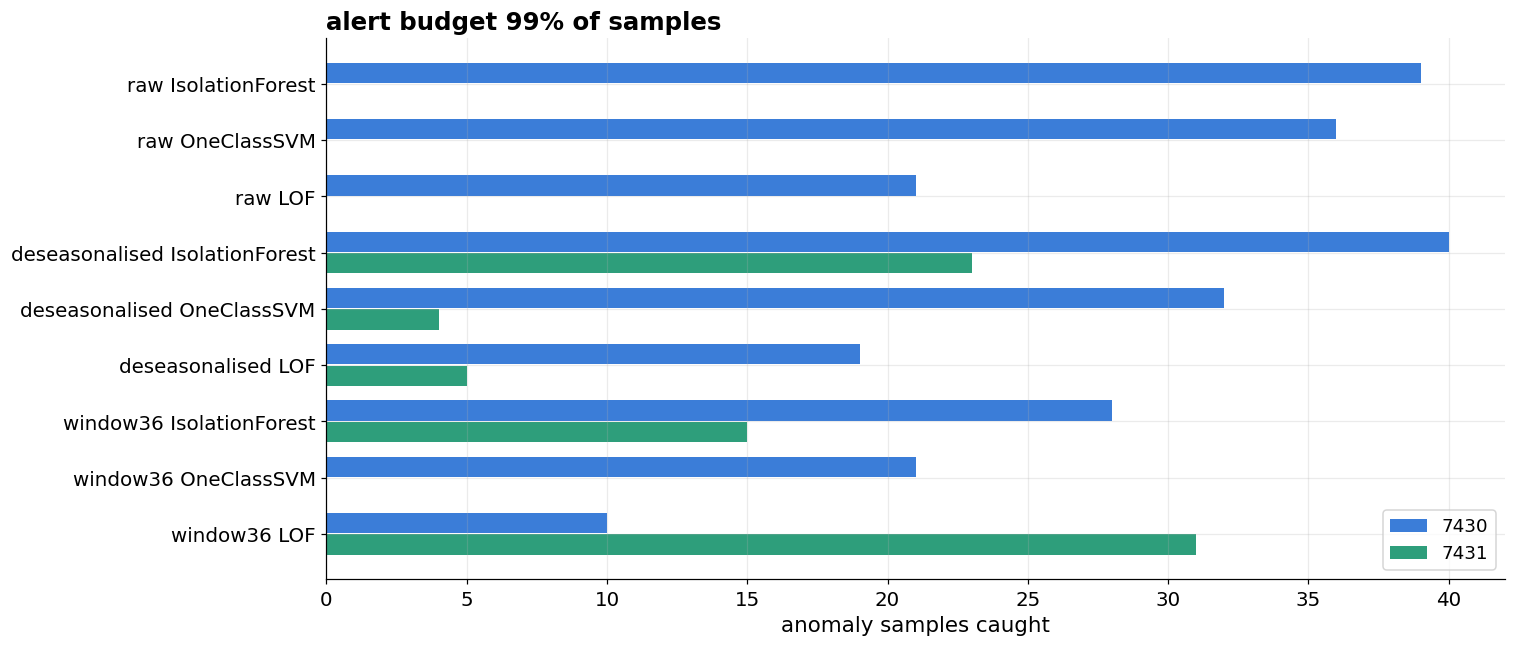

,port,method,alerts,caught,of,precision
0,7431,raw IsolationForest,86,0,36,0.000
1,7431,raw OneClassSVM,87,0,36,0.000
2,7431,raw LOF,87,0,36,0.000
3,7430,raw IsolationForest,86,39,40,0.453
4,7430,raw OneClassSVM,87,36,40,0.414
5,7430,raw LOF,87,21,40,0.241
6,7431,deseasonalised IsolationForest,87,23,36,0.264
7,7431,deseasonalised OneClassSVM,87,4,36,0.046
8,7431,deseasonalised LOF,87,5,36,0.057
9,7430,deseasonalised IsolationForest,85,40,40,0.471


In [28]:
summary = (pd.DataFrame(rows).drop_duplicates(subset=["port", "method"])
           .pivot(index="method", columns="port", values="caught").fillna(0).astype(int))
order = [f"{p} {m}" for p in ("raw", "deseasonalised", f"window{N_INPUT}")
         for m in ("IsolationForest", "OneClassSVM", "LOF")]
summary = summary.reindex([m for m in order if m in summary.index])

w, h = plt.rcParams["figure.figsize"]
fig, ax = plt.subplots(figsize=(w, 0.5 * len(summary) + 1.6))
y = np.arange(len(summary))
for k, port in enumerate(summary.columns):
    ax.barh(y + (k - 0.5) * 0.38, summary[port], height=0.36,
            color=[C["signal"], C["peer"]][k % 2], label=port)
ax.set_yticks(y, summary.index)
ax.invert_yaxis()
ax.set(xlabel="anomaly samples caught", title=f"alert budget {BUDGET:.0%} of samples")
ax.legend()
plt.show()

pd.DataFrame(rows).drop_duplicates(subset=["port", "method"])

Read the two ports as two different problems. `port-id7430`'s events are absolute: raw scoring
already works, and every later step costs it accuracy. `port-id7431`'s event is contextual: raw
scoring finds nothing at all, and the remedies recover between 4 and 31 of its 36 samples
depending on which pairing you pick.

No row wins both columns. That is the lab's actual result, and it is more useful than a ranking
would have been. Feature engineering that encodes time matters more here than the choice of model,
and picking it wrong costs you on the anomalies that did not need it.

The matrix profile is not in this chart, for the reason given at Step 7. Judged on its own terms
it was the strongest single result in the notebook: rank-1 discord on both ports, one parameter,
no training, no scaler, no split.

### Which to reach for first

Start with what is explainable and deployable, and make complexity earn its place:

| situation | first choice |
|---|---|
| a hard limit exists | a rule: safety ceiling, SLO, error budget |
| one signal, clear pattern | a statistical baseline; remove or model the seasonality first |
| several signals interacting | ML, but only after it is compared against a fixed threshold and a rolling z-score |

These layer rather than compete. A fixed threshold underneath a statistical baseline underneath a
model is a normal production stack, not indecision.

## Exercises

Six measurements, then four designs that need what you know about your own network.

### Measure it

1. **Window length.** Set `N_INPUT` to `12`, then `288`, and re-run Step 10. At `288` the detection
   collapses. Explain it from the definition of the window, and check it against the sweep figure.
2. **Subsequence length.** Set `SUBSEQ` to `PERIOD // 4`, then `PERIOD * 2`, and re-run Step 7. Does
   the top discord stay on the anomaly, and does the sweep predict what you see?
3. **CUSUM slack.** Set `k` to `0.25` and then `3.0` in Step 11. `k` is the deviation you agree to
   ignore. How does the alarm count move, and which value would you defend to an on-call team?
4. **EWMA memory.** In Step 12, set `lam` to `0.05` and then `0.8`, and watch both the alert count
   and the delay to first alert. Then remove the `/ limit` from `ewma_score` and re-run: which
   lambda still fires, and does the `implied_threshold_if_unscaled` column explain which ones do not?
5. **The cap.** In Step 13, set `CAP` to `1e6`, effectively removing it, and re-run. The
   `q = 0.995` row for all 13 columns comes back to life. What replaces the cap as the failure, and
   which of the two failures would you rather debug at 03:00?
6. **Composition rule.** Replace `max(axis=1)` with `mean(axis=1)` and then with
   `(z > 4).sum(axis=1)`, a vote count. Max ignores agreement, mean dilutes, voting needs a quorum
   you have to choose. Score all three at `q = 0.995` and say which one you would ship.

### Design it

7. **Which family fits your team?** Step 14's table separates statistical baselines from models. The
   real difference is not accuracy, it is maintenance: a fixed rule needs a human to pick a line for
   every new metric and then holds forever, while a model needs nobody to pick a line and instead
   needs somebody to confirm periodically that the training period still represents normal. Write
   down which of those two costs your team can actually carry, and what would have to change for the
   other one to become affordable.

8. **Explain a model score to your on-call.** A z-score of 4 is four standard deviations from normal.
   An isolation score of 0.6384 is nothing anybody can defend in a review. Draft the two sentences
   you would put in the alert payload for a model-based detector, then decide whether those two
   sentences are enough to justify waking someone. If they are not, that is an argument for keeping
   a statistical detector in front of the model rather than behind it.

9. **Design the seasonal bucket your traffic actually has.** `decompose` assumes one daily period.
   Real networks have month-end batch runs, quarterly closes, semester boundaries, holidays. Write
   the bucket key you would need for one service you support, then say honestly how much history you
   would need before each bucket held enough samples to be worth anything, and whether you have it.

10. **Pick the swap that would break production.** Step 14 says everything downstream of the score is
    detector-agnostic except the threshold, since 4.0 means nothing on a model score. Take one alert
    rule you own today and write what would happen if somebody swapped its scoring function and left
    the constant. Then write the check that would have caught it before it shipped. Most teams find
    the check is easier to write than the incident review.

In [29]:
# YOUR CODE HERE

## Summary

**Seasonality is a property of the data, not a nuisance.** The autocorrelation and the daily
profile identify it in two plots, and everything downstream depends on the period they give.

**Split by index and fit the scaler on the training part.** A random split or a globally fitted
scaler leaks the future backwards, and the result is a number that will not survive production.

**The matrix profile is a strong baseline for one parameter.** No training, no labels, one
subsequence length, and its rank-1 discord landed inside a anomaly window on both ports. That one
parameter behaves exactly like Lab 01's baseline window: it fails short and it fails long.

**A contextual anomaly is invisible to a model with no clock.** Three standard detectors on raw
values caught nothing on `port-id7431`. Deseasonalising recovered 23 of 36 samples with
`IsolationForest`; sliding windows recovered 31 with `LocalOutlierFactor`. Neither changed the
model, and each cost accuracy on the port whose events were already absolute.

**A change point is an investigation, not a verdict.** The largest level changes in this month are
weekends. Correlate against the change calendar before anyone is paged.

Both labs scored one signal at a time. The anomalies that stayed invisible here, the broadcast storm
and the multicast flooding, are visible in a **ratio** between two counters, which is where
multivariate detection starts.